# Library


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
!pip install Sastrawi
!pip install pyLDAvis gensim
!pip install indoNLP
!pip install nlp-id

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Topic modeling & Skenario 2
import pyLDAvis
import pyLDAvis.lda_model # Changed from pyLDAvis.sklearn
import gensim
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.corpora.dictionary import Dictionary
# Ensure pyLDAvis is enabled for notebook display
pyLDAvis.enable_notebook()
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Skenario 3
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Skenario 4 - Slang Normalization, CountVectorizer with n-gram
from indoNLP.preprocessing import replace_slang

# Skenario 5 - StopWords and Stemming using nlp-id
from nlp_id.stopword import StopWord
from nlp_id.lemmatizer import Lemmatizer

# modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Load Dataset

In [ ]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


# Topic Modeling dengan LDA

## Topic Modeling untuk Sentimen Positif

In [ ]:
warnings.filterwarnings('ignore')
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


In [ ]:
df_sentiment_2 = df[df['sentiment'] == 2]
print(df_sentiment_2.head())

       keyword     video_id  \
47  dolar naik  D9hrcadwS-A   
56  dolar naik  D9hrcadwS-A   
58  dolar naik  D9hrcadwS-A   
59  dolar naik  D9hrcadwS-A   
60  dolar naik  D9hrcadwS-A   

                                              comment  sentiment  \
47  Prof ferry mantap bisa membuat jubir pemerinta...          2   
56  Semoga Rupiah segera kembali stabil dan kondis...          2   
58  Optimis Indonesia mampu melewati tantangan glo...          2   
59  Semoga langkah yang diambil pemerintah bisa me...          2   
60  Memang kondisi global lagi berat, tapi semoga ...          2   

                                    processed_comment  
47  profferrymantapbisamembuatjubirpemerintahterta...  
56  semogarupiahsegerakembalistabildankondisiekono...  
58  optimisindonesiamampumelewatitantanganglobalka...  
59  semogalangkahyangdiambilpemerintahbisamenjagad...  
60  memangkondisigloballagiberattapisemogaindonesi...  


In [ ]:
df_sentiment_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 955 entries, 47 to 16090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   keyword            955 non-null    object
 1   video_id           955 non-null    object
 2   comment            955 non-null    object
 3   sentiment          955 non-null    int64 
 4   processed_comment  930 non-null    object
dtypes: int64(1), object(4)
memory usage: 44.8+ KB


DataFrame shape after preprocessing and dropping empty comments: (930, 5)
Calculating coherence for 2 topics...
Calculating coherence for 3 topics...
Calculating coherence for 4 topics...
Calculating coherence for 5 topics...
Calculating coherence for 6 topics...
Calculating coherence for 7 topics...
Calculating coherence for 8 topics...
Calculating coherence for 9 topics...
Calculating coherence for 10 topics...


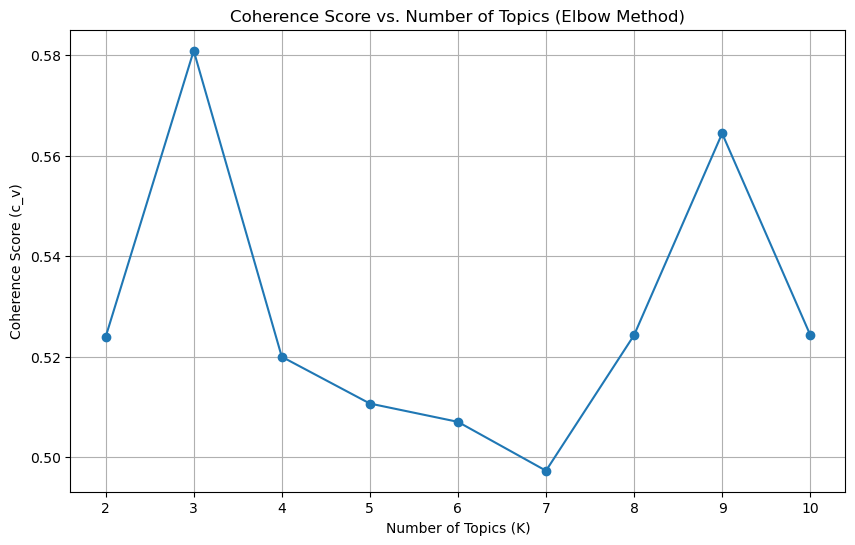


Optimal number of topics based on highest coherence score: 3
Highest coherence score: 0.5809

--- Top words for 3 topics (Optimal Model) ---
Topic 1:
dollar dolar rupiah negeri pemerintah orang barang harga desa aja pake prabowo masyarakat gak nya hidup beli pakai rakyat maju
Topic 2:
indonesia ekonomi prabowo kuat budiman masyarakat pemerintah bangsa rakyat maju membangun mandiri dolar semoga desa jaga menjaga semangat global mas
Topic 3:
indonesia imf negara rupiah asing uang amerika dunia mata rakyat bank nilai presiden ekonomi dolar tdk dgn melemah nya antek

--- Intertopic Distance Map ---


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.213725  0.092139       1        1  42.219239
2     -0.018802 -0.224254       2        1  34.988226
0     -0.194923  0.132115       3        1  22.792535, topic_info=           Term        Freq       Total Category  logprob  loglift
53          imf  225.000000  225.000000  Default  30.0000  30.0000
112      negara  189.000000  189.000000  Default  29.0000  29.0000
33       dollar   90.000000   90.000000  Default  28.0000  28.0000
56    indonesia  541.000000  541.000000  Default  27.0000  27.0000
37      ekonomi  246.000000  246.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
94   masyarakat   26.888226  106.869325   Topic3  -3.9385   0.0988
146    semangat   20.141593   53.584028   Topic3  -4.2274   0.5003
133     prabowo   28.847209  164.919321   Topic3  -3.8682  -0.2647
141      rakyat   23.672874  110.460437   Topic3  -4.0659  -0.0616
88         maju   21.084906   87.390500   Topic3  -4.1817   0.0569

[163 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         2  0.023057      aja
0         3  0.968375      aja
2         2  0.989714  amerika
3         2  0.988194    antek
5         2  0.988429    asing
...     ...       ...      ...
168       1  0.292123    turun
168       3  0.701094    turun
169       2  0.897168     uang
169       3  0.092810     uang
170       2  0.969000    utang

[187 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1])

Intertopic Distance Map saved to lda_intertopic_distance_map_positif.html


In [ ]:
# --- 1. Data Preparation ---
# Use df_sentiment_2 as the base for this analysis
df_lda = df_sentiment_2.copy()
df_lda['comment'] = df_lda['comment'].astype(str)

# Download Indonesian stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column
df_lda['processed_comment'] = df_lda['comment'].apply(preprocess_text)

# Drop rows where 'processed_comment' is empty after preprocessing
df_lda.dropna(subset=['processed_comment'], inplace=True)
df_lda = df_lda[df_lda['processed_comment'].str.strip() != '']

print(f"DataFrame shape after preprocessing and dropping empty comments: {df_lda.shape}")

# --- 2. Determine Optimal Number of Topics using Coherence Score (Elbow Method) ---
def calculate_coherence_scores(dataframe, text_column, start=2, limit=16, step=1, max_df=0.90, min_df=0.01):
    coherence_values = []
    model_list = []
    k_values = range(start, limit, step)

    # Fit vectorizer once on the full processed data for consistency
    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words=list(stop_words_indonesian))
    dtm = vectorizer.fit_transform(dataframe[text_column])
    feature_names = vectorizer.get_feature_names_out()

    # Prepare tokenized comments for Gensim CoherenceModel
    tokenized_comments = [doc.split() for doc in dataframe[text_column]]
    # Filter tokens to only include those present in the CountVectorizer's vocabulary
    filtered_tokenized_comments = []
    vocabulary_set = set(feature_names)
    for doc_tokens in tokenized_comments:
        filtered_doc = [token for token in doc_tokens if token in vocabulary_set]
        if filtered_doc:
            filtered_tokenized_comments.append(filtered_doc)

    # Create Gensim dictionary and corpus from filtered tokens
    gensim_dictionary = Dictionary(filtered_tokenized_comments)
    corpus = [gensim_dictionary.doc2bow(doc) for doc in filtered_tokenized_comments]

    for num_topics in k_values:
        print(f"Calculating coherence for {num_topics} topics...")
        # Create and fit the LDA model
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(dtm)
        model_list.append(lda_model)

        # Extract topics (words) for coherence model
        topics_words = []
        for topic in lda_model.components_:
            # Ensure no_top_words is not greater than the number of available features in the topic
            no_top_words_for_coherence = min(10, len(feature_names)) # Using 10 as default for display_topics
            top_word_indices = topic.argsort()[:-no_top_words_for_coherence - 1:-1]
            topics_words.append([feature_names[i] for i in top_word_indices])

        # Calculate coherence score
        coherence_model = CoherenceModel(topics=topics_words, texts=filtered_tokenized_comments,
                                         dictionary=gensim_dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    return k_values, coherence_values, model_list, dtm, vectorizer

# Calculate coherence scores for a range of topics
k_values, coherence_scores, lda_models, dtm_final, vectorizer_final = calculate_coherence_scores(
    df_lda, 'processed_comment', start=2, limit=11, step=1) # Testing from 2 to 10 topics

# Plot the coherence scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics (Elbow Method)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the optimal number of topics (can be adjusted visually from the plot)
# For programmatic selection, we'll pick the one with the highest coherence for demonstration.
optimal_num_topics_index = coherence_scores.index(max(coherence_scores))
optimal_num_topics = k_values[optimal_num_topics_index]
optimal_lda_model = lda_models[optimal_num_topics_index]

print(f"\nOptimal number of topics based on highest coherence score: {optimal_num_topics}")
print(f"Highest coherence score: {max(coherence_scores):.4f}")

# --- 3. Display Top Word Topics for the Optimal Model ---
print(f"\n--- Top words for {optimal_num_topics} topics (Optimal Model) ---")
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 20 # Display 10 top words for each topic
display_topics(optimal_lda_model, vectorizer_final.get_feature_names_out(), no_top_words)

# --- 4. Show and Save Intertopic Distance Map ---
print("\n--- Intertopic Distance Map ---")
# Prepare the data for pyLDAvis using the optimal LDA model, DTM, and vectorizer
pyldavis_data = pyLDAvis.lda_model.prepare(optimal_lda_model, dtm_final, vectorizer_final, mds='mmds')

# Display the visualization interactively in the notebook
display(pyldavis_data)

# Save the visualization as an HTML file
output_filename = 'lda_intertopic_distance_map_positif.html'
pyLDAvis.save_html(pyldavis_data, output_filename)
print(f"Intertopic Distance Map saved to {output_filename}")

## Topic Modeling untuk Sentimen Negatif

In [ ]:
df = pd.read_csv('Labeled_Dataset.csv')
df.head()

,keyword,video_id,comment,sentiment,processed_comment
0,dolar naik,D9hrcadwS-A,Budi budi kucing peliharaan meong meong🎉🎉🎉,0,budibudikucingpeliharaanmeongmeong
1,dolar naik,D9hrcadwS-A,Budiman gak pernah dikasih buat mempertebal po...,0,budimangakpernahdikasihbuatmempertebalpoinargu...
2,dolar naik,D9hrcadwS-A,Anis mah apa2an ngak jelas,0,anismahapaanngakjelas
3,dolar naik,D9hrcadwS-A,Budiman mending jadi admin jula jula aja😂,0,budimanmendingjadiadminjulajulaaja
4,dolar naik,D9hrcadwS-A,"Yang menciptakan kata omon""",0,yangmenciptakankataomon


In [ ]:
df_sentiment_0 = df[df['sentiment'] == 0]
print(df_sentiment_0.head())

      keyword     video_id                                            comment  \
0  dolar naik  D9hrcadwS-A         Budi budi kucing peliharaan meong meong🎉🎉🎉   
1  dolar naik  D9hrcadwS-A  Budiman gak pernah dikasih buat mempertebal po...   
2  dolar naik  D9hrcadwS-A                         Anis mah apa2an ngak jelas   
3  dolar naik  D9hrcadwS-A          Budiman mending jadi admin jula jula aja😂   
4  dolar naik  D9hrcadwS-A                        Yang menciptakan kata omon"   

   sentiment                                  processed_comment  
0          0                 budibudikucingpeliharaanmeongmeong  
1          0  budimangakpernahdikasihbuatmempertebalpoinargu...  
2          0                              anismahapaanngakjelas  
3          0                 budimanmendingjadiadminjulajulaaja  
4          0                            yangmenciptakankataomon  


In [ ]:
df_sentiment_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14696 entries, 0 to 16147
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   keyword            14696 non-null  object
 1   video_id           14696 non-null  object
 2   comment            14696 non-null  object
 3   sentiment          14696 non-null  int64 
 4   processed_comment  14544 non-null  object
dtypes: int64(1), object(4)
memory usage: 688.9+ KB


DataFrame shape after preprocessing and dropping empty comments: (14512, 5)
Calculating coherence for 2 topics...
Calculating coherence for 3 topics...
Calculating coherence for 4 topics...
Calculating coherence for 5 topics...
Calculating coherence for 6 topics...
Calculating coherence for 7 topics...
Calculating coherence for 8 topics...
Calculating coherence for 9 topics...
Calculating coherence for 10 topics...


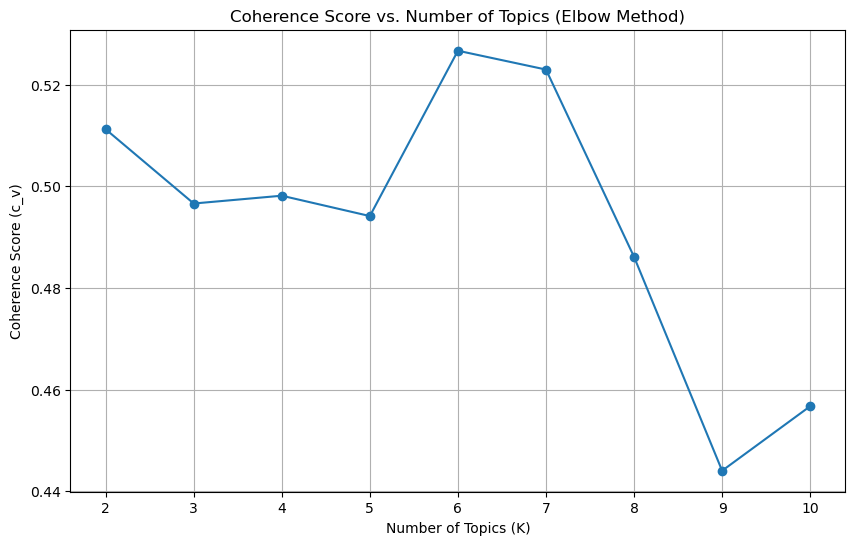


Optimal number of topics based on highest coherence score: 6
Highest coherence score: 0.5267

--- Top words for 6 topics (Optimal Model) ---
Topic 1:
presiden aja budiman anak prabowo udah ngomong paham gini banget purbaya sih wowo cerdas penjilat pintar sekelas ekonomi kayak malu
Topic 2:
presiden mbg pake desa dolar pakai nya gak dollar makan bang emang otak dah tempe goblok aja kedelai kali jago
Topic 3:
orang rakyat gak omon bodoh desa presiden nya aja tau pinter bikin pemimpin doang pidato pejabat ngomong ngerti kaya org
Topic 4:
rupiah prabowo dollar uang wowo mata nilai negara indonesia dolar imf kalo melemah asing antek impor pakai krisis lemah pemerintahan
Topic 5:
negara indonesia pemimpin ekonomi nya tdk amerika pilih salah pemerintah dgn sdh bangsa prof buzzer suka konoha korupsi semoga dunia
Topic 6:
harga nya dolar barang pemerintah rakyat beli masyarakat aja mahal bahan impor kerja turun hasil tolol biar indonesia gak kebutuhan

--- Intertopic Distance Map ---


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.251833  0.249515       1        1  17.585577
0     -0.063047 -0.352881       2        1  17.389194
5      0.077615  0.258438       3        1  16.846940
2      0.295799  0.075097       4        1  16.617390
1      0.224214 -0.169714       5        1  16.301085
3     -0.282748 -0.060454       6        1  15.259815, topic_info=           Term         Freq        Total Category  logprob  loglift
209       orang  1427.000000  1427.000000  Default  30.0000  30.0000
254      rakyat  1570.000000  1570.000000  Default  29.0000  29.0000
258      rupiah   997.000000   997.000000  Default  28.0000  28.0000
243    presiden  2138.000000  2138.000000  Default  27.0000  27.0000
190      negara  1295.000000  1295.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
103   indonesia   246.667219  1345.827761   Topic6  -3.6536   0.1832
100       impor   140.219665   426.631272   Topic6  -4.2184   0.7672
215       pakai   137.845952   481.850888   Topic6  -4.2355   0.6284
223  pemerintah    97.988151   712.780588   Topic6  -4.5768  -0.1044
294        udah    94.308890   475.035765   Topic6  -4.6151   0.2631

[287 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
0         1  0.039033    aja
0         2  0.450874    aja
0         3  0.181624    aja
0         4  0.176844    aja
0         5  0.115506    aja
...     ...       ...    ...
299       3  0.877857  warga
299       4  0.119320  warga
300       2  0.340222   wowo
300       5  0.001745   wowo
300       6  0.657762   wowo

[588 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 1, 6, 3, 2, 4])

Intertopic Distance Map saved to lda_intertopic_distance_map_negatif.html


In [ ]:
# --- 1. Data Preparation ---
# Use df_sentiment_0 as the base for this analysis
df_lda = df_sentiment_0.copy()
df_lda['comment'] = df_lda['comment'].astype(str)

# Download Indonesian stopwords if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column
df_lda['processed_comment'] = df_lda['comment'].apply(preprocess_text)

# Drop rows where 'processed_comment' is empty after preprocessing
df_lda.dropna(subset=['processed_comment'], inplace=True)
df_lda = df_lda[df_lda['processed_comment'].str.strip() != '']

print(f"DataFrame shape after preprocessing and dropping empty comments: {df_lda.shape}")

# --- 2. Determine Optimal Number of Topics using Coherence Score (Elbow Method) ---
def calculate_coherence_scores(dataframe, text_column, start=2, limit=16, step=1, max_df=0.70, min_df=0.004):
    coherence_values = []
    model_list = []
    k_values = range(start, limit, step)

    # Fit vectorizer once on the full processed data for consistency
    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words=list(stop_words_indonesian))
    dtm = vectorizer.fit_transform(dataframe[text_column])
    feature_names = vectorizer.get_feature_names_out()

    # Prepare tokenized comments for Gensim CoherenceModel
    tokenized_comments = [doc.split() for doc in dataframe[text_column]]
    # Filter tokens to only include those present in the CountVectorizer's vocabulary
    filtered_tokenized_comments = []
    vocabulary_set = set(feature_names)
    for doc_tokens in tokenized_comments:
        filtered_doc = [token for token in doc_tokens if token in vocabulary_set]
        if filtered_doc:
            filtered_tokenized_comments.append(filtered_doc)

    # Create Gensim dictionary and corpus from filtered tokens
    gensim_dictionary = Dictionary(filtered_tokenized_comments)
    corpus = [gensim_dictionary.doc2bow(doc) for doc in filtered_tokenized_comments]

    for num_topics in k_values:
        print(f"Calculating coherence for {num_topics} topics...")
        # Create and fit the LDA model
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
        lda_model.fit(dtm)
        model_list.append(lda_model)

        # Extract topics (words) for coherence model
        topics_words = []
        for topic in lda_model.components_:
            # Ensure no_top_words is not greater than the number of available features in the topic
            no_top_words_for_coherence = min(10, len(feature_names)) # Using 10 as default for display_topics
            top_word_indices = topic.argsort()[:-no_top_words_for_coherence - 1:-1]
            topics_words.append([feature_names[i] for i in top_word_indices])

        # Calculate coherence score
        coherence_model = CoherenceModel(topics=topics_words, texts=filtered_tokenized_comments,
                                         dictionary=gensim_dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())

    return k_values, coherence_values, model_list, dtm, vectorizer

# Calculate coherence scores for a range of topics
k_values, coherence_scores, lda_models, dtm_final, vectorizer_final = calculate_coherence_scores(
    df_lda, 'processed_comment', start=2, limit=11, step=1) # Testing from 2 to 10 topics

# Plot the coherence scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_scores, marker='o')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics (Elbow Method)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find the optimal number of topics (can be adjusted visually from the plot)
# For programmatic selection, we'll pick the one with the highest coherence for demonstration.
optimal_num_topics_index = coherence_scores.index(max(coherence_scores))
optimal_num_topics = k_values[optimal_num_topics_index]
optimal_lda_model = lda_models[optimal_num_topics_index]

print(f"\nOptimal number of topics based on highest coherence score: {optimal_num_topics}")
print(f"Highest coherence score: {max(coherence_scores):.4f}")

# --- 3. Display Top Word Topics for the Optimal Model ---
print(f"\n--- Top words for {optimal_num_topics} topics (Optimal Model) ---")
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 20 # Display 10 top words for each topic
display_topics(optimal_lda_model, vectorizer_final.get_feature_names_out(), no_top_words)

# --- 4. Show and Save Intertopic Distance Map ---
print("\n--- Intertopic Distance Map ---")
# Prepare the data for pyLDAvis using the optimal LDA model, DTM, and vectorizer
pyldavis_data = pyLDAvis.lda_model.prepare(optimal_lda_model, dtm_final, vectorizer_final, mds='mmds')

# Display the visualization interactively in the notebook
display(pyldavis_data)

# Save the visualization as an HTML file
output_filename = 'lda_intertopic_distance_map_negatif.html'
pyLDAvis.save_html(pyldavis_data, output_filename)
print(f"Intertopic Distance Map saved to {output_filename}")

# Handle imbalance dataset

Dalam segmen ini, kita perlu melakukan perlakuan khusus pada data yang saat ini kita miliki dikarenakan sifat datanya yang sangat condong ke satu label saja. Sehingga kita perlu mengurangi data yang memiliki label dominan dan membuat data baru untuk label yang memiliki jumlah data kecil untuk kita seimbangkan rasionya sehingga ukurannya seimbang untuk setiap label.

Perlakuan ini diperlukan agar tidak terjadinya overfitting yang diakibatkan karena model melakukan training pada dataset yang condong pada satu label saja.

Dalam bagian pre-processing ini, kami menerapkan undersampling dan Data Augmentation sehingga pada akhirnya total data training yang akan digunakan menjadi 6000 dengan pembagian 2000 data untuk setiap labelnya. (80 % dari 7500 = 6000)

## Undersampling

In [ ]:
x = df['comment']
y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,      # 20% data digunakan untuk testing
    random_state=67,     # Mengunci 'seed' agar hasil split selalu sama setiap kali di-run
    stratify=y           # Menjaga proporsi kelas tetap seimbang antara train dan test
)

In [ ]:
sum_positif = (y_train == 2).sum()
sum_netral = (y_train == 1).sum()
# testing = 6000 data
str_undersampling = {
    0: 2000,
    1: sum_netral,
    2: sum_positif
}

rus = RandomUnderSampler(sampling_strategy=str_undersampling, random_state=67)

X_train_df = X_train.to_frame()

# 4. Lakukan Fit dan Resample
X_train_rus, y_train_rus = rus.fit_resample(X_train_df, y_train)

# 5. Kembalikan X_train menjadi format Series 1D (teks biasa)
X_train_rus = X_train_rus['comment']

# --- Validasi Hasil ---
print("=== Distribusi Label SEBELUM Undersampling ===")
print(y_train.value_counts())

print("\n=== Distribusi Label SETELAH Undersampling ===")
print("Sekarang kelas 0 sudah dipangkas, siap untuk augmentasi kelas 1 dan 2:")
print(y_train_rus.value_counts())

=== Distribusi Label SEBELUM Undersampling ===
sentiment
0    11756
2      764
1      398
Name: count, dtype: int64

=== Distribusi Label SETELAH Undersampling ===
Sekarang kelas 0 sudah dipangkas, siap untuk augmentasi kelas 1 dan 2:
sentiment
0    2000
2     764
1     398
Name: count, dtype: int64


## Oversampling - Data Augmentation


In [ ]:
kamus_sinonim = {
    "bagus": ["keren", "mantap", "kece", "oke", "top", "gokil"],
    "suka": ["demen", "cinta", "seneng"],
    "banget": ["sekali", "pisan", "betul", "parah"],
    "bermanfaat": ["berguna", "membantu", "edukatif"],
    "video": ["konten", "vidio", "vlog", "tayangan"],
    "jelek": ["buruk", "parah", "sampah", "kurang"],
    "setuju": ["sepakat", "bener", "valid"],
    "untung": ["cuan", "profit", "hijau", "luber", "cair", "panen"],
    "aman": ["terkendali", "stabil", "tenang", "selamat", "santai"],
    "bagus": ["mantap", "cerdas", "oke", "top", "keren", "bijak"],
    "peluang": ["kesempatan", "momen", "waktu yang pas"],
    "pemerintah": ["penguasa", "pejabat", "pusat", "pemerintahan", "negara", "pemimpin"],
    "rakyat": ["masyarakat", "warga", "kita", "rakyat kecil", "wong cilik", "umr"],
    "dollar": ["usd", "dolar", "dolar as", "uang asing", "greenback"],
    "rupiah": ["rp", "idr", "mata uang kita", "uang kita"],
    "ekonomi": ["keuangan", "finansial", "pasar", "keadaan"],
    "investasi": ["porto", "portofolio", "saham", "aset", "simpanan", "reksadana", "tabungan"],
    "beli": ["serok", "borong", "tampung", "ambil", "masuk"],
    "jual": ["lepas", "buang", "take profit", "cut loss", "keluar"],
    "tahan": ["hold", "simpan", "tunggu", "wait and see"],
    "gaji": ["pendapatan", "penghasilan", "pemasukan", "upah"],
    "lanjut": ["next", "part 2", "up", "request", "lanjutkan", "bahas ini bang"],
    "tertawa": ["ngakak", "wkwkwk", "kocak", "bengek", "awokawok", "lucu banget", "bikin mual"],
    "dukung": ["semangat", "support", "sukses terus", "maju terus", "gas", "kawal", "kembangkan"],
    "inspirasi": ["panutan", "motivasi", "teladan", "idola", "menginspirasi", "bikin melek", "buka mata"],
    "pintar": ["jenius", "suhu", "master", "pakar", "berilmu", "pro", "otak encer", "paham banget"],
    "jelas": ["paham", "mengerti", "gamblang", "masuk akal", "gampang dicerna", "mudah dipahami", "terang benderang"],
    "terimakasih": ["makasih", "thank you", "tq", "suwun", "nuhun", "thanks bang", "makasih ilmunya"],
    "hormat": ["respect", "salut", "angkat topi", "sungkem", "respek", "kelas", "luar biasa"],
    "berkualitas": ["daging semua", "premium", "bukan kaleng-kaleng", "berbobot", "bergizi", "berkelas"],
    "doa": ["amin", "berkah", "sehat selalu", "lancar rezeki", "barokah", "panjang umur", "semoga sukses"],
    "nyaman": ["adem", "healing", "bikin tenang", "betah", "enak diliat", "santuy", "vibesnya dapet"],
    "bangga": ["proud", "merinding", "terharu", "ikut seneng", "membanggakan", "terbaik"],
    "ramah": ["humble", "rendah hati", "merakyat", "sopan", "baik banget", "gak sombong"],
    "tidak": ["gak", "ga", "nggak", "g", "kagak", "ndak", "tdk"],
    "yang": ["yg"],
    "sudah": ["udah", "udh", "sdh", "dah"],
    "belum": ["belom", "blm", "blom"],
    "kalau": ["kalo", "klo", "kl", "kalu"],
    "karena": ["karna", "krn", "gara-gara", "gegara"],
    "seperti": ["kayak", "kyk", "kek", "spt"],
    "bagaimana": ["gimana", "gmn", "bgmn", "cemana"],
    "dengan": ["dgn", "ama", "sama"],
    "terus": ["trus", "trs"],
    "tapi": ["tp"],
    "bisa": ["bs", "bise"],
    "banyak": ["bnyk", "byk"],
    "sekarang": ["skrg"],
    "orang": ["org", "hooman"],
    "saja": ["aja", "aj", "sj", "za"],
    "lagi": ["lg"],
    "untuk": ["utk", "buat", "bt"],
    "sangat": ["bgt", "banget", "pisan"],
    "iya": ["y", "ya", "yoi", "yep"],
    "omon": ["omon-omon", "omong kosong", "bualan", "cakap doang", "teori saja", "banyak bicara", "pepesan kosong"],
    "buzzer": ["pendengung", "akun bayaran", "pasukan siber", "bot", "pendukung bayaran"],
    "nyebokin": ["membela", "menutupi kesalahan", "membersihkan nama", "mencari-cari alasan", "membenarkan"],
    "penjilat": ["pencari muka", "kacung", "antek", "loyalis buta", "penjilat pantat"],
    "blunder": ["salah langkah", "keliru", "salah ucap", "kesalahan fatal", "terpeleset lidah"],
    "ngawur": ["asal-asalan", "sembarangan", "melantur", "tidak masuk akal", "asbun", "asal bunyi"],
    "setingan": ["rekayasa", "buatan", "manipulasi", "pura-pura", "settingan"],
    "wowo": ["prabowo", "02", "pak prabowo", "pak presiden"],
    "keren": ["mantap", "hebat", "luar biasa", "bagus", "jempolan", "memukau"],
    "kecewa": ["tidak puas", "nyesel", "menyesal", "patah hati", "hilang harapan"],
    "bodoh": ["bego", "dungu", "tolol", "pandir", "tidak pintar", "kurang akal"],
    "kuat": ["stabil", "tangguh", "kokoh", "tahan banting", "seimbang", "normal", "mapan"],
    "optimis": ["yakin", "percaya diri", "berpikiran positif", "penuh harapan"],
    "hancur": ["rusak", "binasa", "runtuh", "berantakan", "amburadul"],
    "panik": ["takut", "khawatir", "gelisah", "cemas"],
    "susah": ["sulit", "melarat", "miskin", "menderita"],
    "krisis": ["resesi", "kemelut", "kemerosotan", "masa sulit", "kejatuhan"],
    "ekonomi": ["perekonomian", "finansial", "keuangan"],
    "utang": ["hutang", "pinjaman", "tunggakan", "kewajiban", "kredit"],
    "korupsi": ["rasuah", "penggelapan uang", "penyelewengan", "maling uang rakyat"],
    "pemerintah": ["penguasa", "rezim", "kabinet", "negara"],
    "rakyat": ["masyarakat", "warga", "publik", "penduduk", "orang kecil", "rayat"],
    "pejabat": ["aparatur", "birokrat", "pemimpin", "petinggi"],
    "kebijakan": ["aturan", "regulasi", "keputusan", "langkah"],
    "dukung": ["mendukung", "menyokong", "membela", "membantu", "mendorong", "memihak"],
    "menata": ["membenahi", "memperbaiki", "merapikan", "mengurus", "mengelola"],
    "melumpuhkan": ["mematahkan", "mengalahkan", "membungkam", "menundukkan"],
    "menjaga": ["merawat", "melindungi", "mempertahankan", "mengawal"],
    "bekerja": ["bertugas", "berupaya", "berusaha", "mengabdi"],
    "berjuang": ["bertarung", "berusaha keras", "mengerahkan tenaga"],
    "yg": ["yang"],
    "gk": ["gak", "nggak", "enggak", "tidak", "tdk"],
    "dng": ["dengan", "dgn"],
    "bgt": ["banget", "sekali", "pisan"],
    "mbg": ["makan bergizi gratis", "program makan siang", "makan siang gratis"],
    "oligarki": ["penguasa kapitalis", "elite politik", "kartel", "cukong"],
    "oposisi": ["tim lawan", "pihak kontra", "pengkritik", "pembangkang", "kubu lawan"],
    "bancakan": ["korupsi berjamaah", "bagi-bagi jatah", "pesta pora uang rakyat", "jarahan"],
    "amburadul": ["berantakan", "kacau balau", "carut marut", "tidak teratur", "rusak"],
    "nyinyir": ["mencibir", "mengkritik tajam", "julid", "berkomentar pedas", "asal kritik"],
    "lemot": ["lambat", "telat mikir", "tumpul", "lelet", "lamban"],
    "bodok": ["bodoh", "bego", "dungu", "tolol", "kurang akal", "pandir"],
    "downgrade": ["merendahkan", "menjatuhkan", "mengurangi nilai", "mendiskreditkan"],
    "air keras": ["ancaman fisik", "teror", "intimidasi"],
    "kestabilan": ["keseimbangan", "kemantapan", "stabilitas"],
    "tengkulak": ["pengepul", "lintah darat", "makelar", "perantara"],
    "kapitalis": ["pemilik modal", "konglomerat", "swasta besar"],
    "inflasi": ["kenaikan harga barang", "kemerosotan nilai uang", "lonjakan harga"],
    "devisa": ["cadangan uang negara", "pendapatan negara", "valuta asing"],
    "intervensi": ["campur tangan", "keterlibatan", "tindakan penstabilan", "turun tangan"],
    "mandiri": ["berdikari", "tidak bergantung", "otonom", "berdiri sendiri"],
    "bangkit": ["maju", "berkembang", "pulih", "bangun dari keterpurukan"],
    "terbungkam": ["terdiam", "mati kutu", "bungkam", "tidak bisa menjawab", "patah argumen"],
    "nyata": ["konkret", "jelas", "terbukti", "riil", "faktual"],
    "fleksibel": ["luwes", "mudah menyesuaikan", "adaptif"],
    "ga": ["gak", "nggak", "enggak", "tidak", "tdk"],
    "emg": ["memang", "emang"],
    "pd": ["pada", "daripada"],
    "utk": ["untuk", "buat"],
    "dl": ["dulu", "dahulu", "sebelumnya"],
    "ja": ["saja", "aja"]
}

In [ ]:
def random_swap(sentence, n=1):
    """Menukar posisi dua kata secara acak di dalam kalimat."""
    words = str(sentence).split()
    if len(words) < 2: # Tidak bisa ditukar jika hanya 1 kata
        return sentence
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_deletion(sentence, p=0.15):
    """Menghapus kata secara acak dengan probabilitas p."""
    words = str(sentence).split()
    if len(words) == 1: # Jangan hapus jika sisa 1 kata
        return sentence
    # Simpan kata jika probabilitas acak lebih besar dari p
    new_words = [word for word in words if random.uniform(0, 1) > p]
    if len(new_words) == 0:
        return random.choice(words)
    return ' '.join(new_words)

def synonym_replacement(sentence, kamus, n=1):
    """
    Mengganti maksimal 'n' kata dalam kalimat dengan sinonimnya.
    """
    words = str(sentence).split()
    new_words = words.copy()

    # Cari kata-kata dalam kalimat (yang diubah ke huruf kecil) yang ada di kamus
    kata_cocok = [word for word in words if word.lower() in kamus]

    # Jika tidak ada kata yang cocok dengan kamus, kembalikan kalimat asli
    if not kata_cocok:
        return sentence

    # Pilih maksimal n kata secara acak untuk diganti
    jumlah_ganti = min(n, len(kata_cocok))
    kata_yang_diganti = random.sample(kata_cocok, jumlah_ganti)

    for word in kata_yang_diganti:
        # Pilih satu sinonim secara acak dari list di kamus
        sinonim_pilihan = random.choice(kamus[word.lower()])

        # Cari posisi indeks kata tersebut dan ganti dengan sinonimnya
        for i, w in enumerate(new_words):
            if w.lower() == word.lower():
                new_words[i] = sinonim_pilihan
                break # Ganti satu saja lalu lanjut ke kata berikutnya

    return ' '.join(new_words)


def augmentasi_data_minoritas(teks_list, jumlah_target):
    """Membuat teks sintetik hingga mencapai jumlah target."""
    teks_sintetik = []
    jumlah_saat_ini = len(teks_list)
    jumlah_kekurangan = jumlah_target - jumlah_saat_ini
    counters=0
    counterm=0

    # Ubah ke list murni untuk optimasi kecepatan iterasi
    teks_list = list(teks_list)

    while len(teks_sintetik) < jumlah_kekurangan:
        # 1. Ambil teks asli secara acak dari data yang ada
        teks_asli = random.choice(teks_list)

        # 2. Pilih teknik augmentasi secara acak
        # Tambahkan [0] di akhir untuk mengekstrak string dari dalam list
        teknik = random.choices(['swap', 'delete', 'synonim'], weights=[0.2, 0, 0.8], k=1)[0]

        if teknik == 'swap':
            teks_baru = random_swap(teks_asli)
            counters = counters + 1
        elif teknik == 'synonim':
            teks_baru = synonym_replacement(teks_asli, kamus_sinonim, n=2)
            counterm = counterm + 1
        else:
            teks_baru = random_deletion(teks_asli)

        teks_sintetik.append(teks_baru)

    return teks_sintetik,counters,counterm

# ==========================================
# PROSES UTAMA AUGMENTASI KELAS 1 & 2
# ==========================================
# Asumsi: X_train_rus dan y_train_rus adalah output dari Langkah 2

# 1. Satukan sementara ke dalam DataFrame untuk memudahkan filter data
df_train_rus = pd.DataFrame({'comment': X_train_rus, 'sentiment': y_train_rus})

teks_negatif = df_train_rus[df_train_rus['sentiment'] == 0]['comment']
teks_netral  = df_train_rus[df_train_rus['sentiment'] == 1]['comment']
teks_positif = df_train_rus[df_train_rus['sentiment'] == 2]['comment']

# 2. Tentukan target ekuilibrium (menyamai jumlah kelas 0 hasil undersampling)
TARGET_POS = 2000
TARGET_NET = 2000

print("Mulai membuat data sintetik untuk Kelas 1 (Netral)...")
sintetik_netral,counter1s,counter1m = augmentasi_data_minoritas(teks_netral, TARGET_NET)

print("Mulai membuat data sintetik untuk Kelas 2 (Positif)...")
sintetik_positif,counter2s,counter2m = augmentasi_data_minoritas(teks_positif, TARGET_POS)

# 3. Bungkus data sintetik ke dalam format DataFrame
df_sintetik_netral = pd.DataFrame({'comment': sintetik_netral, 'sentiment': 1})
df_sintetik_positif = pd.DataFrame({'comment': sintetik_positif, 'sentiment': 2})

# 4. Gabungkan semua data (Asli hasil Undersampling + Sintetik Baru)
df_train_final = pd.concat([
    df_train_rus,
    df_sintetik_netral,
    df_sintetik_positif
], ignore_index=True)

# 5. Acak (Shuffle) urutan barisnya! Sangat krusial agar model tidak
#    belajar secara berurutan (negatif semua, lalu netral semua, dll).
df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Ekstrak kembali menjadi format Series 1D
x_train_final = df_train_final['comment']
y_train_final = df_train_final['sentiment']

# --- Validasi Akhir ---
print("\n=== Distribusi Label PADA DATA TRAINING FINAL ===")
print("Data ini sekarang seimbang dan siap diekstraksi fitur (misal: TF-IDF):")
print(y_train_final.value_counts())
print(counter1s+counter2s)
print(counter1m+counter2m)

Mulai membuat data sintetik untuk Kelas 1 (Netral)...
Mulai membuat data sintetik untuk Kelas 2 (Positif)...

=== Distribusi Label PADA DATA TRAINING FINAL ===
Data ini sekarang seimbang dan siap diekstraksi fitur (misal: TF-IDF):
sentiment
0    2000
1    2000
2    2000
Name: count, dtype: int64
566
2272


In [ ]:
x_trainn = 'x_train_final.csv'
y_trainn = 'y_train_final.csv'

# Ekstrak DataFrame ke file CSV
x_train_final.to_csv(x_trainn, index=False, encoding='utf-8')
y_train_final.to_csv(y_trainn, index=False, encoding='utf-8')

print(f"Sukses! Data training seimbang berhasil disimpan di: {x_trainn}")
print(f"Jumlah baris yang disimpan: {len(df_train_final)} baris.")

Sukses! Data training seimbang berhasil disimpan di: x_train_final.csv
Jumlah baris yang disimpan: 6000 baris.


In [ ]:
xtestdf = pd.read_csv('x_test_final.csv')
ytestdf = pd.read_csv('y_test_final.csv')

X_test = xtestdf['comment']
y_test = ytestdf['sentiment']
print(y_test.value_counts())

sentiment
1    500
2    500
0    500
Name: count, dtype: int64


# Skenario 1 - Fauzan

In [ ]:
# ==========================================
# SKENARIO 1 - Tanpa Pre-processing
# ==========================================

x1_train = x_train_final.copy()
y1_train = y_train_final.copy()

x1_test = X_test.copy()
y1_test = y_test.copy()

print("Jumlah data training :", len(x1_train))
print("Jumlah data testing  :", len(x1_test))

Jumlah data training : 6000
Jumlah data testing  : 1500


In [ ]:
x1_train = x1_train.fillna('')
x1_test  = x1_test.fillna('')

vectorizer1 = TfidfVectorizer(max_features=10000)

# fit_transform pada data training (sudah di-stem)
X1_train_tfidf = vectorizer1.fit_transform(x1_train)
X1_test_tfidf   = vectorizer1.transform(x1_test)

print("Shape X3_train_tfidf :", X1_train_tfidf.shape)
print("Shape X3_test_tfidf  :", X1_test_tfidf.shape)

Shape X3_train_tfidf : (6000, 8138)
Shape X3_test_tfidf  : (1500, 8138)



=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.81      0.68       500
     Neutral       0.78      0.50      0.61       500
    Positive       0.83      0.81      0.82       500

    accuracy                           0.71      1500
   macro avg       0.73      0.71      0.70      1500
weighted avg       0.73      0.71      0.70      1500

Confusion Matrix:


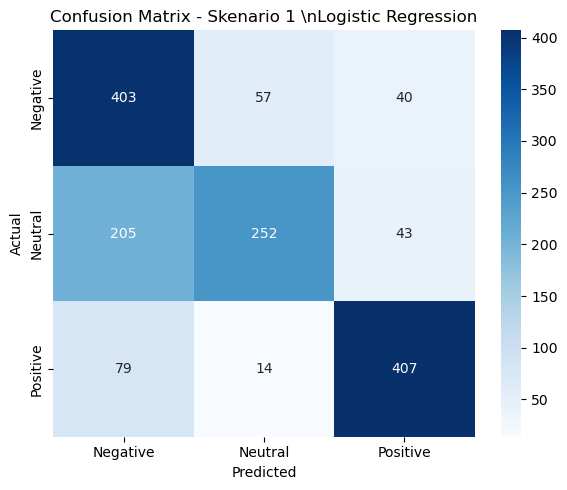


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.73      0.64       500
     Neutral       0.80      0.37      0.51       500
    Positive       0.70      0.89      0.78       500

    accuracy                           0.66      1500
   macro avg       0.69      0.66      0.64      1500
weighted avg       0.69      0.66      0.64      1500

Confusion Matrix:


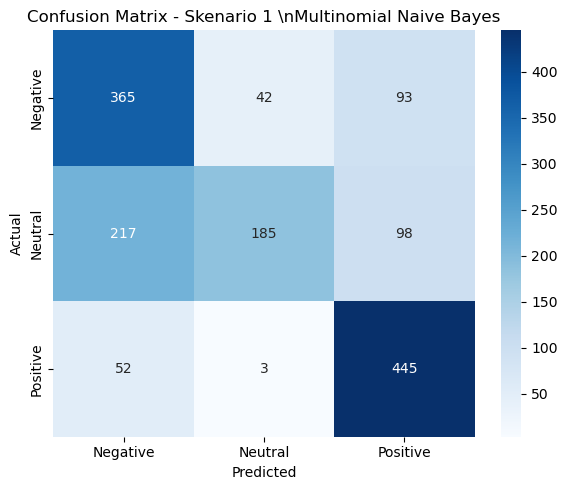


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.93      0.69       500
     Neutral       0.88      0.42      0.57       500
    Positive       0.92      0.77      0.84       500

    accuracy                           0.71      1500
   macro avg       0.78      0.71      0.70      1500
weighted avg       0.78      0.71      0.70      1500

Confusion Matrix:


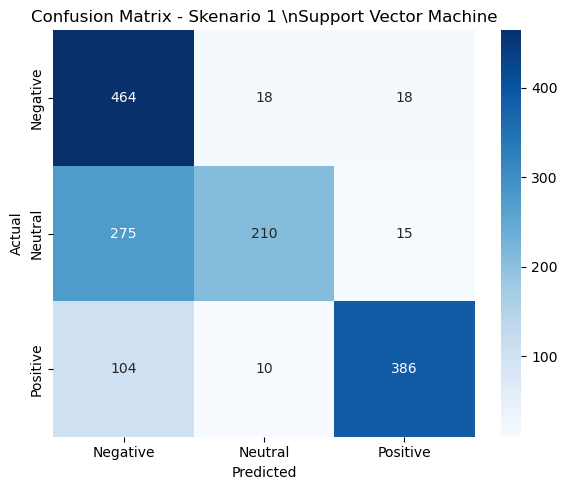


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       500
     Neutral       0.80      0.60      0.68       500
    Positive       0.84      0.76      0.80       500

    accuracy                           0.72      1500
   macro avg       0.75      0.72      0.72      1500
weighted avg       0.75      0.72      0.72      1500

Confusion Matrix:


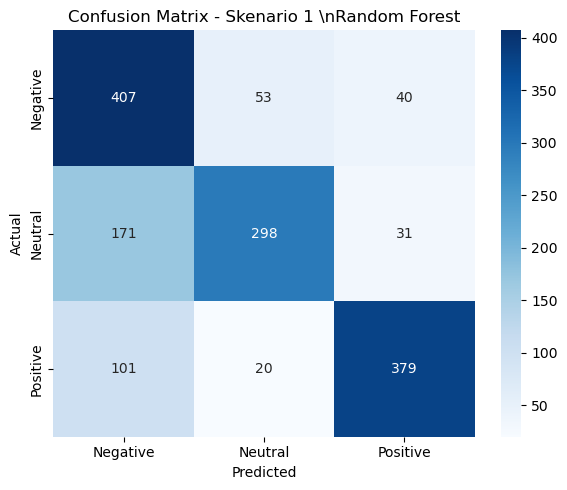


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.73      0.67       500
     Neutral       0.74      0.65      0.69       500
    Positive       0.83      0.78      0.80       500

    accuracy                           0.72      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.73      0.72      0.72      1500

Confusion Matrix:


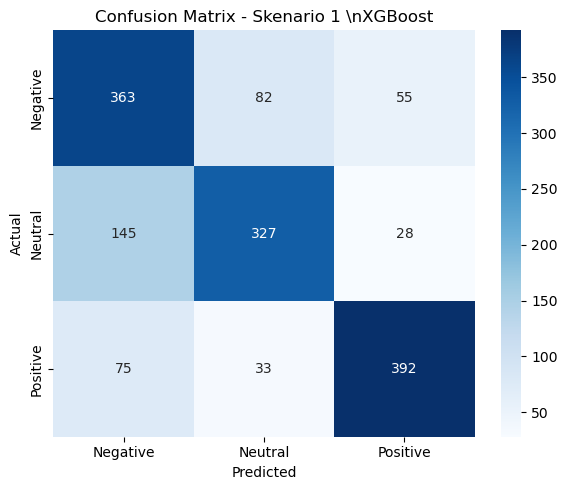


=== Perbandingan Performa Model (Skenario 1 - Stemming) ===
Metric                            Accuracy  F1-score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.679023   0.586608   0.806   
                        Neutral        NaN  0.612394   0.780186   0.504   
                        Overall   0.708000       NaN        NaN     NaN   
                        Positive       NaN  0.822222   0.830612   0.814   
Multinomial Naive Bayes Negative       NaN  0.643739   0.575710   0.730   
                        Neutral        NaN  0.506849   0.804348   0.370   
                        Overall   0.663333       NaN        NaN     NaN   
                        Positive       NaN  0.783451   0.699686   0.890   
Random Forest           Negative       NaN  0.690416   0.599411   0.814   
                        Neutral        NaN  0.684271   0.803235   0.596   
                        Overall   0.722

In [ ]:
# ==========================================
# Training Model
# ==========================================

models1 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

target_names1 = ['Negative', 'Neutral', 'Positive']
results1 = []

for name, model in models1.items():
    print(f"\n=== {name} ===")

    # train
    model.fit(X1_train_tfidf, y1_train)

    # prediksi
    y1_pred = model.predict(X1_test_tfidf)

    # evaluasi
    report   = classification_report(y1_test, y1_pred, target_names=target_names1, output_dict=True)
    accuracy = accuracy_score(y1_test, y1_pred)

    for class_label in target_names1:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            results1.append({
                'Model' : name,
                'Metric': metric.replace('-score', '-Score').capitalize(),
                'Class' : class_label,
                'Score' : report[class_label][metric]
            })

    results1.append({
        'Model' : name,
        'Metric': 'Accuracy',
        'Class' : 'Overall',
        'Score' : accuracy
    })

    print("Classification Report:")
    print(classification_report(y1_test, y1_pred, target_names=target_names1))

    print("Confusion Matrix:")
    cm1 = confusion_matrix(y1_test, y1_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names1, yticklabels=target_names1)
    plt.title(f'Confusion Matrix - Skenario 1 \\n{name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# buat dataframe perbandingan hasil
df1 = pd.DataFrame(results1)
pivot1 = df1.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')
print("\n=== Perbandingan Performa Model (Skenario 1 - Stemming) ===")
print(pivot1)

=== Ringkasan Test Accuracy (Skenario 1 - Stemming) ===
                  Model  Test Accuracy
          Random Forest       0.722667
                XGBoost       0.721333
    Logistic Regression       0.708000
 Support Vector Machine       0.706667
Multinomial Naive Bayes       0.663333


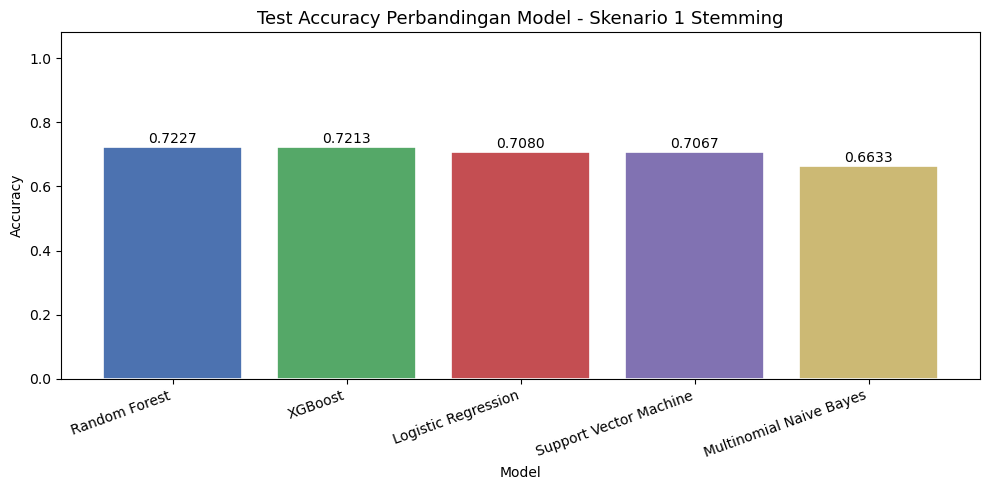

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy1_summary = (
    df1[
        (df1['Metric'] == 'Accuracy') &
        (df1['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy1_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 1 - Stemming) ===')
print(accuracy1_summary.to_string(index=False))

colors1 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars1 = plt.bar(
    accuracy1_summary['Model'],
    accuracy1_summary['Test Accuracy'],
    color=colors1[:len(accuracy1_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars1:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 1 Stemming', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 2 - Willy

In [ ]:
# ==========================================
# SKENARIO 2 - Stopwords Removal
# ==========================================

x2_train = x_train_final.copy()
y2_train = y_train_final.copy()

x2_test = X_test.copy()
y2_test = y_test.copy()

print("Jumlah data training :", len(x2_train))
print("Jumlah data testing  :", len(x2_test))

Jumlah data training : 6000
Jumlah data testing  : 1500


In [ ]:
# Load the training and testing data (assuming they are saved as CSVs)
X_train = pd.read_csv('x_train_final.csv')
X_test = pd.read_csv('x_test_final.csv')
y_train = pd.read_csv('y_train_final.csv').iloc[:, 0] # Assuming sentiment is the first column
y_test = pd.read_csv('y_test_final.csv').iloc[:, 0]


=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.78      0.69       500
     Neutral       0.78      0.58      0.67       500
    Positive       0.86      0.85      0.85       500

    accuracy                           0.74      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.75      0.74      0.74      1500

Confusion Matrix:


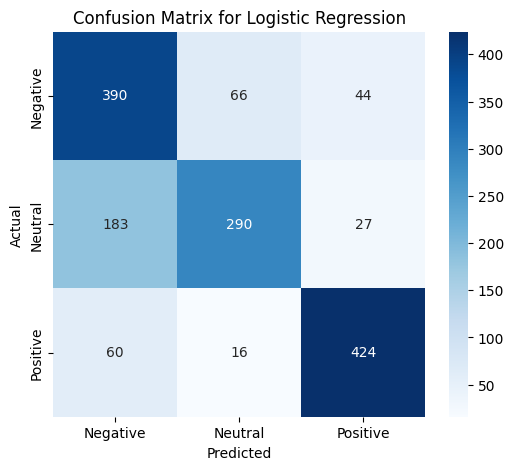


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.78      0.66       500
     Neutral       0.83      0.41      0.55       500
    Positive       0.73      0.85      0.79       500

    accuracy                           0.68      1500
   macro avg       0.71      0.68      0.67      1500
weighted avg       0.71      0.68      0.67      1500

Confusion Matrix:


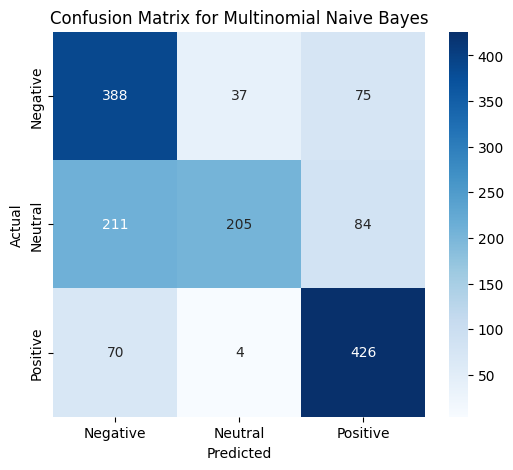


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.89      0.70       500
     Neutral       0.85      0.48      0.61       500
    Positive       0.91      0.80      0.85       500

    accuracy                           0.72      1500
   macro avg       0.78      0.72      0.72      1500
weighted avg       0.78      0.72      0.72      1500

Confusion Matrix:


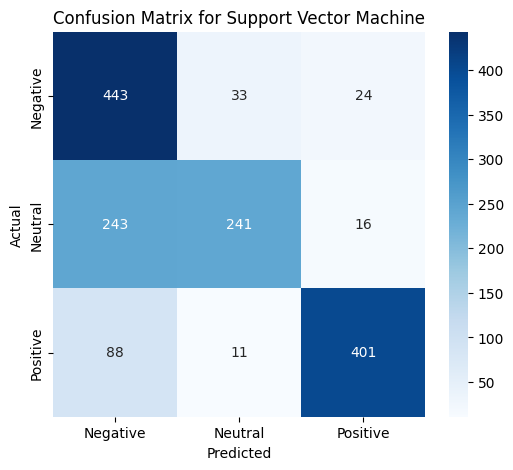


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.75      0.68       500
     Neutral       0.77      0.63      0.69       500
    Positive       0.84      0.81      0.82       500

    accuracy                           0.73      1500
   macro avg       0.74      0.73      0.73      1500
weighted avg       0.74      0.73      0.73      1500

Confusion Matrix:


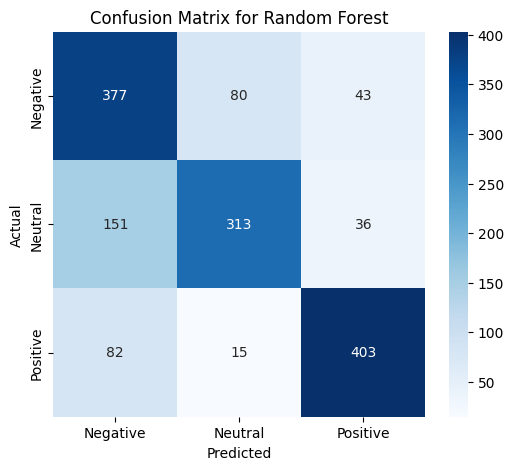


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.70      0.68       500
     Neutral       0.73      0.71      0.72       500
    Positive       0.86      0.82      0.84       500

    accuracy                           0.74      1500
   macro avg       0.75      0.74      0.75      1500
weighted avg       0.75      0.74      0.75      1500

Confusion Matrix:


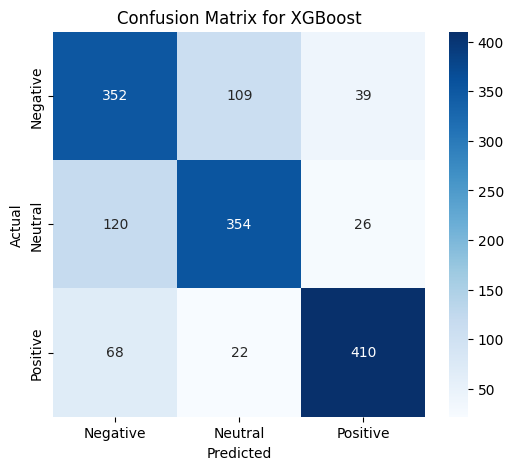


=== Model Performance Comparison ===
Metric                            Accuracy  F1-Score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.688438   0.616114   0.780   
                        Neutral        NaN  0.665138   0.779570   0.580   
                        Overall   0.736000       NaN        NaN     NaN   
                        Positive       NaN  0.852261   0.856566   0.848   
Multinomial Naive Bayes Negative       NaN  0.663815   0.579970   0.776   
                        Neutral        NaN  0.549598   0.833333   0.410   
                        Overall   0.679333       NaN        NaN     NaN   
                        Positive       NaN  0.785253   0.728205   0.852   
Random Forest           Negative       NaN  0.679279   0.618033   0.754   
                        Neutral        NaN  0.689427   0.767157   0.626   
                        Overall   0.728667       NaN        Na

In [ ]:
import nltk
from nltk.corpus import stopwords
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure NLTK stopwords are downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    tokens = text.split()
    # Remove stopwords and very short words (e.g., single letters)
    tokens = [word for word in tokens if word not in stop_words_indonesian and len(word) > 2]
    return ' '.join(tokens)

# Apply preprocessing to the 'comment' column for training and test sets
X_train['processed_comment'] = X_train['comment'].apply(preprocess_text)
X_test['processed_comment'] = X_test['comment'].apply(preprocess_text)

# Drop rows where 'processed_comment' might have become empty after preprocessing
X_train.dropna(subset=['processed_comment'], inplace=True)
X_test.dropna(subset=['processed_comment'], inplace=True)

# Align y_train and y_test with the potentially dropped rows
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

# --- TF-IDF Vectorization ---
vectorizer = TfidfVectorizer(max_features=5000) # Limit features to avoid very high dimensionality
X_train_tfidf = vectorizer.fit_transform(X_train['processed_comment'])
X_test_tfidf = vectorizer.transform(X_test['processed_comment'])

# --- Model Training and Evaluation ---
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine': SVC( random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results = []
target_names = ['Negative', 'Neutral', 'Positive']

for name, model in models.items():
    print(f"\n=== {name} ===")
    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions
    y_pred = model.predict(X_test_tfidf)

    # Evaluate the model
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    # Store results for each class
    for class_label in target_names:
        results.append({
            'Model': name,
            'Metric': 'Precision',
            'Class': class_label,
            'Score': report[class_label]['precision']
        })
        results.append({
            'Model': name,
            'Metric': 'Recall',
            'Class': class_label,
            'Score': report[class_label]['recall']
        })
        results.append({
            'Model': name,
            'Metric': 'F1-Score',
            'Class': class_label,
            'Score': report[class_label]['f1-score']
        })
        results.append({
            'Model': name,
            'Metric': 'Support',
            'Class': class_label,
            'Score': report[class_label]['support']
        })

    # Store overall accuracy
    results.append({
        'Model': name,
        'Metric': 'Accuracy',
        'Class': 'Overall',
        'Score': accuracy
    })

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Create a DataFrame from the results
comparison_df = pd.DataFrame(results)

# Pivot the table for better readability
pivot_table = comparison_df.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')

print("\n=== Model Performance Comparison ===")
print(pivot_table)

=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===
                  Model  Test Accuracy
                XGBoost       0.744000
    Logistic Regression       0.736000
          Random Forest       0.728667
 Support Vector Machine       0.723333
Multinomial Naive Bayes       0.679333


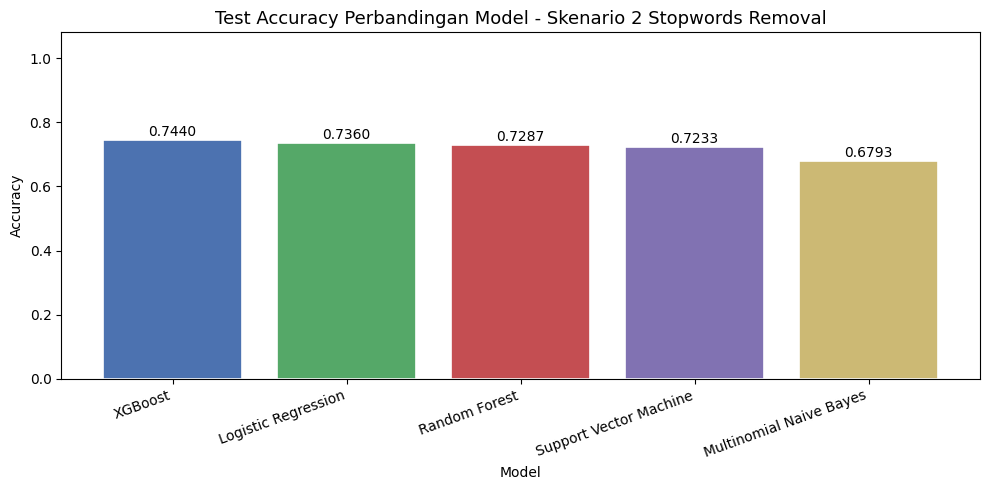

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy2_summary = (
    comparison_df[
        (comparison_df['Metric'] == 'Accuracy') &
        (comparison_df['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy2_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===')
print(accuracy2_summary.to_string(index=False))

colors2 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars2 = plt.bar(
    accuracy2_summary['Model'],
    accuracy2_summary['Test Accuracy'],
    color=colors2[:len(accuracy2_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars2:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 2 Stopwords Removal', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 3 - Rennard

In [ ]:
# ==========================================
# SKENARIO 3 - Preprocessing dengan Stemming
# ==========================================

x3_train = x_train_final.copy()
y3_train = y_train_final.copy()

x3_test = X_test.copy()
y3_test = y_test.copy()

print("Jumlah data training :", len(x3_train))
print("Jumlah data testing  :", len(x3_test))

Jumlah data training : 6000
Jumlah data testing  : 1500


In [ ]:
# ==========================================
# Preprocessing: Stemming menggunakan PySastrawi
# Pipeline: Lowercase → Hapus noise → Tokenisasi → Stemming
# ==========================================

factory3 = StemmerFactory()
stemmer3  = factory3.create_stemmer()

def preprocess_with_stemming(text):
    # Langkah 1: Konversi ke string & lowercase
    text = str(text).lower()

    # Langkah 2: Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Langkah 3: Hapus karakter non-alfabet (angka, emoji, tanda baca, dst.)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Langkah 4: Tokenisasi
    tokens = text.split()

    # Langkah 5: Stemming menggunakan PySastrawi
    stemmed_tokens = [stemmer3.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

# terapin preprocessing pada data training
x3_train = x3_train.apply(preprocess_with_stemming)
print("Contoh hasil stemming:")
print(x3_train.head())

Contoh hasil stemming:
0    yg ada diboock chain apa kabar kira rp pada be...
1    kalo iran bise korut bise cina bisa tolak ment...
2          rakyat di desa kan pakai daun bang ahhahaah
3                 netizen wajib lumpuh akun imf dan wb
4           aku percaya sama visi prabowo soal ekonomi
Name: comment, dtype: object


In [ ]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

# Isi data kosong (NaN) dengan string kosong agar tidak error saat vektorisasi
x3_train = x3_train.fillna('')
x3_test  = x3_test.fillna('')

vectorizer3 = TfidfVectorizer(max_features=10000)

# fit_transform pada data training (sudah di-stem)
X3_train_tfidf = vectorizer3.fit_transform(x3_train)
X3_test_tfidf   = vectorizer3.transform(x3_test)

print("Shape X3_train_tfidf :", X3_train_tfidf.shape)
print("Shape X3_test_tfidf  :", X3_test_tfidf.shape)

Shape X3_train_tfidf : (6000, 6533)
Shape X3_test_tfidf  : (1500, 6533)



=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.79      0.67       500
     Neutral       0.76      0.52      0.62       500
    Positive       0.82      0.79      0.80       500

    accuracy                           0.70      1500
   macro avg       0.72      0.70      0.69      1500
weighted avg       0.72      0.70      0.69      1500

Confusion Matrix:


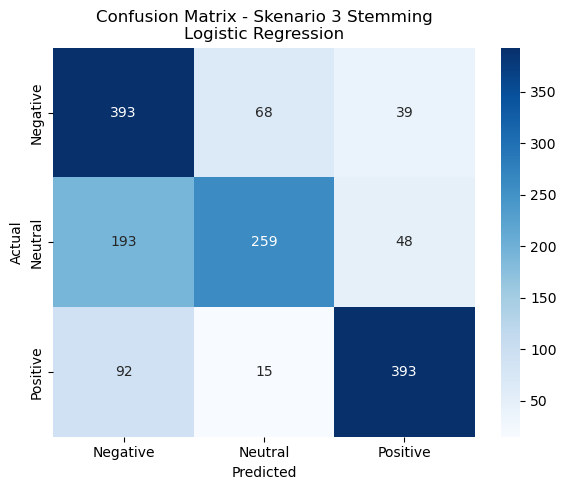


=== Multinomial Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.68      0.62       500
     Neutral       0.78      0.39      0.52       500
    Positive       0.68      0.87      0.76       500

    accuracy                           0.65      1500
   macro avg       0.67      0.65      0.63      1500
weighted avg       0.67      0.65      0.63      1500

Confusion Matrix:


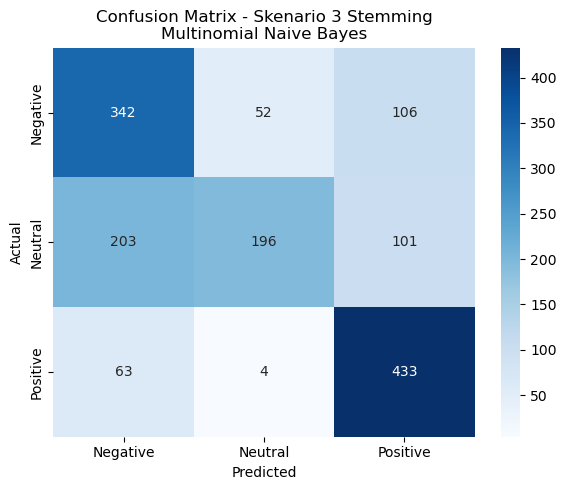


=== Support Vector Machine ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.91      0.68       500
     Neutral       0.85      0.41      0.56       500
    Positive       0.92      0.76      0.83       500

    accuracy                           0.69      1500
   macro avg       0.77      0.69      0.69      1500
weighted avg       0.77      0.69      0.69      1500

Confusion Matrix:


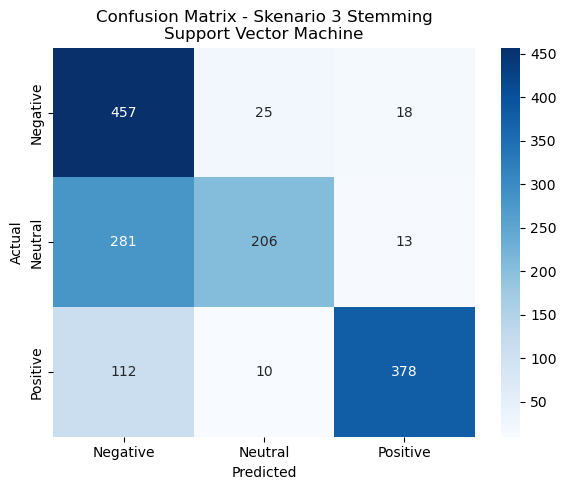


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.80      0.69       500
     Neutral       0.77      0.59      0.67       500
    Positive       0.84      0.75      0.79       500

    accuracy                           0.71      1500
   macro avg       0.73      0.71      0.71      1500
weighted avg       0.73      0.71      0.71      1500

Confusion Matrix:


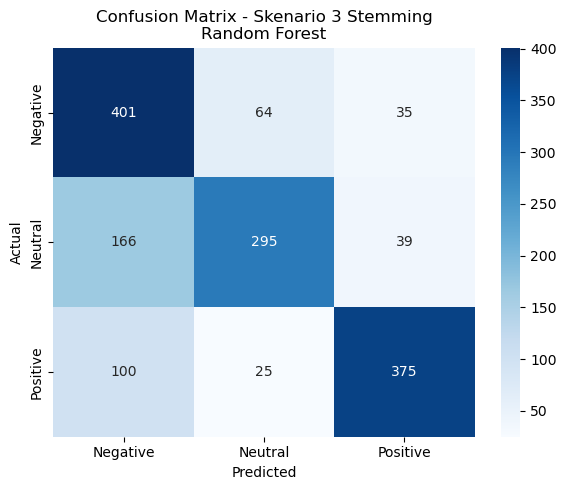


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.70      0.66       500
     Neutral       0.72      0.67      0.69       500
    Positive       0.83      0.78      0.80       500

    accuracy                           0.72      1500
   macro avg       0.72      0.72      0.72      1500
weighted avg       0.72      0.72      0.72      1500

Confusion Matrix:


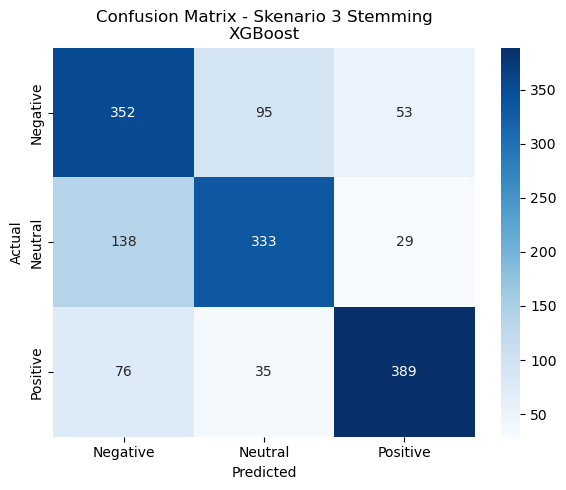


=== Perbandingan Performa Model (Skenario 3 - Stemming) ===
Metric                            Accuracy  F1-score  Precision  Recall  \
Model                   Class                                             
Logistic Regression     Negative       NaN  0.667233   0.579646   0.786   
                        Neutral        NaN  0.615202   0.757310   0.518   
                        Overall   0.696667       NaN        NaN     NaN   
                        Positive       NaN  0.802041   0.818750   0.786   
Multinomial Naive Bayes Negative       NaN  0.617329   0.562500   0.684   
                        Neutral        NaN  0.521277   0.777778   0.392   
                        Overall   0.647333       NaN        NaN     NaN   
                        Positive       NaN  0.759649   0.676562   0.866   
Random Forest           Negative       NaN  0.687232   0.601199   0.802   
                        Neutral        NaN  0.667421   0.768229   0.590   
                        Overall   0.714

In [ ]:
# ==========================================
# Training Model
# ==========================================

models3 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

target_names3 = ['Negative', 'Neutral', 'Positive']
results3 = []

for name, model in models3.items():
    print(f"\n=== {name} ===")

    # train
    model.fit(X3_train_tfidf, y3_train)

    # prediksi
    y3_pred = model.predict(X3_test_tfidf)

    # evaluasi
    report   = classification_report(y3_test, y3_pred, target_names=target_names3, output_dict=True)
    accuracy = accuracy_score(y3_test, y3_pred)

    for class_label in target_names3:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            results3.append({
                'Model' : name,
                'Metric': metric.replace('-score', '-Score').capitalize(),
                'Class' : class_label,
                'Score' : report[class_label][metric]
            })

    results3.append({
        'Model' : name,
        'Metric': 'Accuracy',
        'Class' : 'Overall',
        'Score' : accuracy
    })

    print("Classification Report:")
    print(classification_report(y3_test, y3_pred, target_names=target_names3))

    print("Confusion Matrix:")
    cm3 = confusion_matrix(y3_test, y3_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names3, yticklabels=target_names3)
    plt.title(f'Confusion Matrix - Skenario 3 Stemming\n{name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# buat dataframe perbandingan hasil
df3 = pd.DataFrame(results3)
pivot3 = df3.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')
print("\n=== Perbandingan Performa Model (Skenario 3 - Stemming) ===")
print(pivot3)

=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===
                  Model  Test Accuracy
                XGBoost       0.716000
          Random Forest       0.714000
    Logistic Regression       0.696667
 Support Vector Machine       0.694000
Multinomial Naive Bayes       0.647333


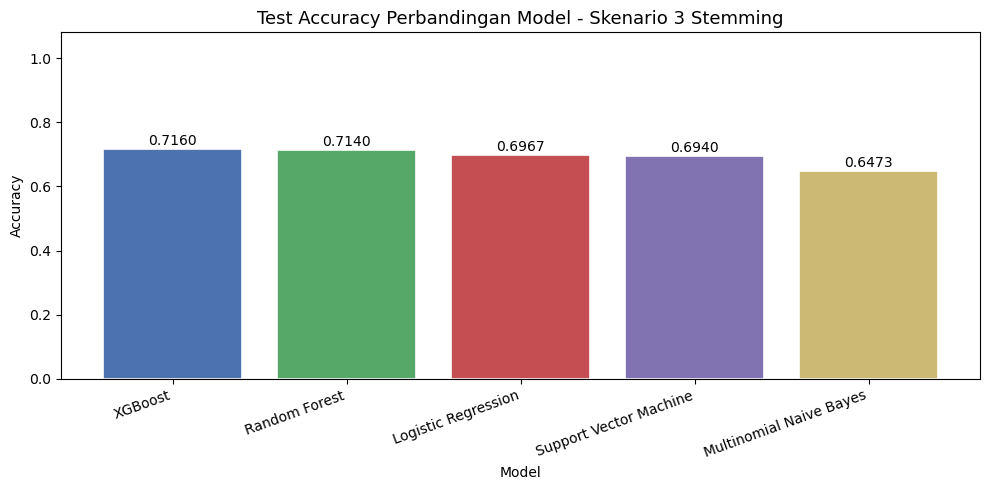

In [ ]:
# ==========================================
# Visualisasi Test Accuracy per Model
# ==========================================

accuracy3_summary = (
    df3[
        (df3['Metric'] == 'Accuracy') &
        (df3['Class']  == 'Overall')
    ][['Model', 'Score']]
    .sort_values('Score', ascending=False)
    .reset_index(drop=True)
)
accuracy3_summary.columns = ['Model', 'Test Accuracy']

print('=== Ringkasan Test Accuracy (Skenario 3 - Stemming) ===')
print(accuracy3_summary.to_string(index=False))

colors3 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
plt.figure(figsize=(10, 5))
bars3 = plt.bar(
    accuracy3_summary['Model'],
    accuracy3_summary['Test Accuracy'],
    color=colors3[:len(accuracy3_summary)],
    edgecolor='white',
    linewidth=1.2
)
for rect in bars3:
    height = rect.get_height()
    plt.text(
        rect.get_x() + rect.get_width() / 2.,
        height + 0.003,
        f'{height:.4f}',
        ha='center', va='bottom', fontsize=10
    )
plt.title('Test Accuracy Perbandingan Model - Skenario 3 Stemming', fontsize=13)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Skenario 4 - Addien

In [ ]:
# ==========================================
# SKENARIO 4 - Preprocessing with IndoNLP Slang Normalizaton, CountVectorizer plus n-Gram
# ==========================================

x4_train = x_train_final.copy()
y4_train = y_train_final.copy()

x4_test = X_test.copy()
y4_test = y_test.copy()

print("Jumlah data training :", len(x4_train))
print("Jumlah data testing  :", len(x4_test))

Jumlah data training : 6000
Jumlah data testing  : 1500


In [ ]:
# ==========================================
# Preprocessing: Slang Normalization menggunakan IndoNLP
# Pipeline: Indo NLP - Slang Normalization
# ==========================================

# IndoNLP : slang normalization
# Mengubah kata-kata tidak baku (slang) menjadi bentuk formal
x4_train = (x4_train.astype(str).apply(replace_slang))
x4_test = (x4_test.astype(str).apply(replace_slang))

# Comparison Visualization : Before & After IndoNLP
# Membandingkan 10 data pertama sebelum dan sesudah normalisasi
comparison = pd.DataFrame({
    'Original': x_train_final.head(10),
    'Normalized': x4_train.head(10)
})
display(comparison)

,Original,Normalized
0,"Yg ada diboock chain apa kabar?, kira2 Rp pada...","yang ada diboock chain apa kabar?, kira-kira R..."
1,Bang knp idr melemah..tolong jelasin.. 😊,Bang kenapa idr melemah..tolong jelasin.. 😊
2,rakyat di desa kan pakai daun bang ahhahaah,rakyat di desa kan pakai daun bang ahhahaah
3,Netizen wajib lumpuhkan akun IMF dan WB 🐶🐖,Netizen wajib lumpuhkan akun IMF dan WB 🐶🐖
4,"Kenapa kita harus tunduk pada negara lain, Ind...","Kenapa kita harus tunduk pada negara lain, Ind..."
5,Dan lucunya pemerintah masih pake dollar..pada...,Dan lucunya pemerintah masih pakai dollar..pad...
6,Sepertinya Tuhan sedang membiarkan Bapak 1 ini...,Sepertinya Tuhan sedang membiarkan Bapak 1 ini...
7,"Malah bagus dong,kita bisa eksport koruptor de...","Malah bagus dong,kita bisa eksport koruptor de..."
8,Masa sekelas presiden saja kalah sama anak kec...,Masa sekelas presiden saja kalah sama anak kec...
9,Influencer buzzer,Influencer buzzer


In [ ]:
# ==========================================
# CountVectorizer & N-Gram (Unigram, Bigram, Trigram)
# ==========================================

# 3.1 Unigram Vectorization
# Mengubah teks menjadi fitur numerik berbasis kata tunggal (1-gram)
cv_uni = CountVectorizer(ngram_range=(1,1))

# 4.1 Transformasi menjadi angka teks dengan fitur unigram
# Fit pada data training, lalu transform training & testing
x4_train_uni = cv_uni.fit_transform(x4_train)
x4_test_uni = cv_uni.transform(x4_test)

# 3.2 Bigram Vectorization
# Menambahkan penggunaan kombinasi kata (1 kata + 2 kata berurutan)
cv_bi = CountVectorizer(ngram_range=(1,2))

# 4.2 Transformasi menjadi angka teks dengan fitur unigram + bigram
# Fit pada data training, lalu transform training & testing
x4_train_bi = cv_bi.fit_transform(x4_train)
x4_test_bi = cv_bi.transform(x4_test)

# 3.3 Trigram Vectorization
# Menambahkan penggunaan kombinasi hingga 3 kata berurutan
cv_tri = CountVectorizer(ngram_range=(1,3))

# 4.3 Transformasi teks menjadi angka dengan fitur unigram + bigram + trigram
# Fit pada data training, lalu transform training & testing
x4_train_tri = cv_tri.fit_transform(x4_train)
x4_test_tri = cv_tri.transform(x4_test)

print("Unigram shape:", x4_train_uni.shape)
print("Bigram shape:", x4_train_bi.shape)
print("Trigram shape:", x4_train_tri.shape)

Unigram shape: (6000, 7539)
Bigram shape: (6000, 43727)
Trigram shape: (6000, 89193)




CONFIG : Unigram

=== Logistic Regression ===
Accuracy : 0.7193

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.77      0.68       500
     Neutral       0.76      0.56      0.64       500
    Positive       0.83      0.83      0.83       500

    accuracy                           0.72      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.73      0.72      0.72      1500



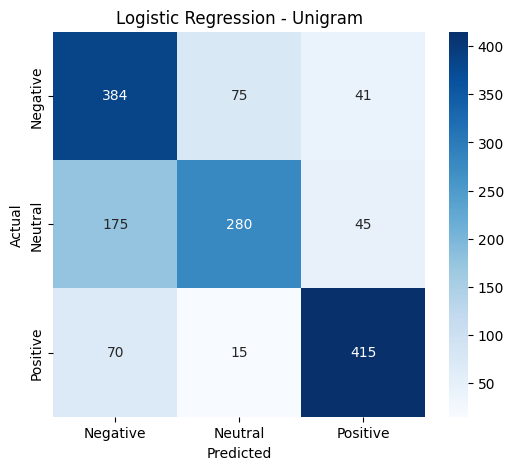


=== Multinomial Naive Bayes ===
Accuracy : 0.6953

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.77      0.67       500
     Neutral       0.82      0.46      0.59       500
    Positive       0.75      0.86      0.80       500

    accuracy                           0.70      1500
   macro avg       0.72      0.70      0.69      1500
weighted avg       0.72      0.70      0.69      1500



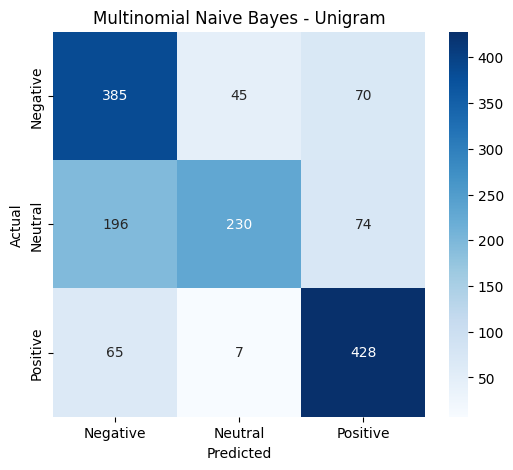


=== Support Vector Machine ===
Accuracy : 0.7053

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.76      0.66       500
     Neutral       0.73      0.64      0.68       500
    Positive       0.86      0.72      0.78       500

    accuracy                           0.71      1500
   macro avg       0.73      0.71      0.71      1500
weighted avg       0.73      0.71      0.71      1500



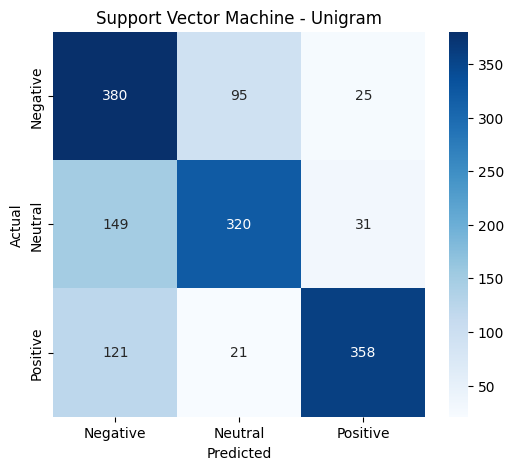


=== Random Forest ===
Accuracy : 0.7187

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       500
     Neutral       0.79      0.57      0.66       500
    Positive       0.84      0.77      0.81       500

    accuracy                           0.72      1500
   macro avg       0.74      0.72      0.72      1500
weighted avg       0.74      0.72      0.72      1500



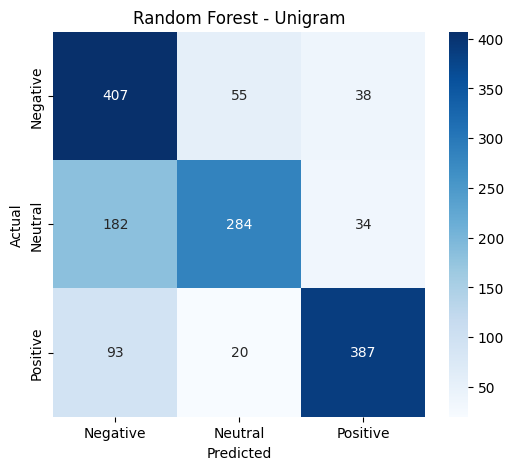


=== XGBoost ===
Accuracy : 0.7313

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.74      0.68       500
     Neutral       0.74      0.63      0.68       500
    Positive       0.85      0.82      0.84       500

    accuracy                           0.73      1500
   macro avg       0.74      0.73      0.73      1500
weighted avg       0.74      0.73      0.73      1500



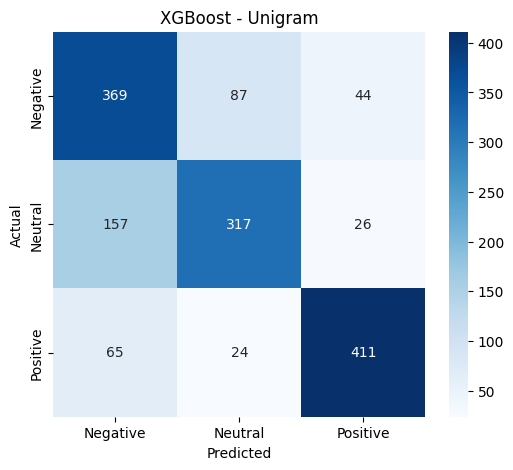



CONFIG : Unigram + Bigram

=== Logistic Regression ===
Accuracy : 0.7280

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.80      0.69       500
     Neutral       0.78      0.59      0.67       500
    Positive       0.87      0.79      0.83       500

    accuracy                           0.73      1500
   macro avg       0.75      0.73      0.73      1500
weighted avg       0.75      0.73      0.73      1500



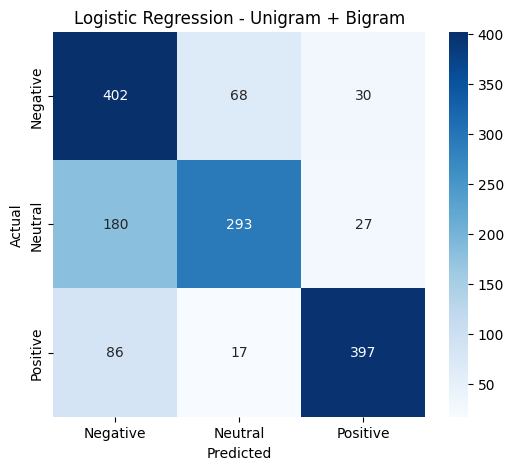


=== Multinomial Naive Bayes ===
Accuracy : 0.6953

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.79      0.68       500
     Neutral       0.87      0.42      0.57       500
    Positive       0.73      0.88      0.80       500

    accuracy                           0.70      1500
   macro avg       0.73      0.70      0.68      1500
weighted avg       0.73      0.70      0.68      1500



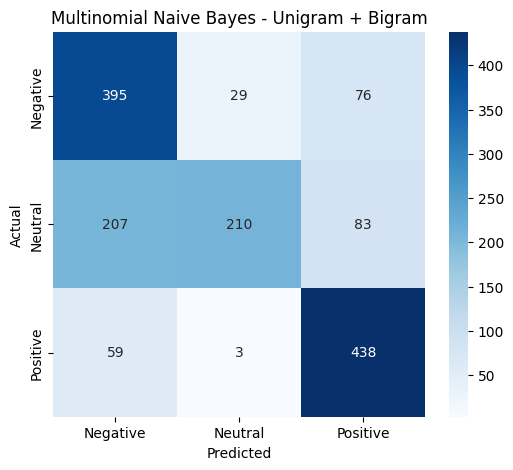


=== Support Vector Machine ===
Accuracy : 0.7067

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.73      0.65       500
     Neutral       0.71      0.67      0.69       500
    Positive       0.87      0.72      0.79       500

    accuracy                           0.71      1500
   macro avg       0.72      0.71      0.71      1500
weighted avg       0.72      0.71      0.71      1500



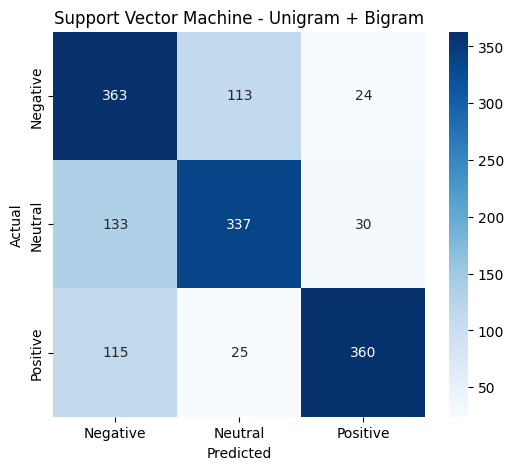


=== Random Forest ===
Accuracy : 0.7247

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       500
     Neutral       0.78      0.61      0.68       500
    Positive       0.88      0.75      0.81       500

    accuracy                           0.72      1500
   macro avg       0.75      0.72      0.73      1500
weighted avg       0.75      0.72      0.73      1500



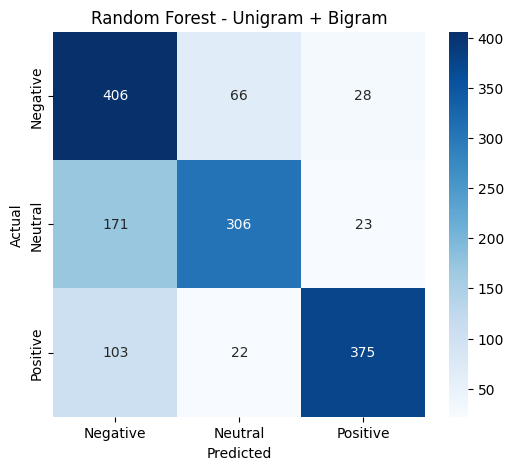


=== XGBoost ===
Accuracy : 0.7280

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.74      0.67       500
     Neutral       0.74      0.63      0.68       500
    Positive       0.85      0.81      0.83       500

    accuracy                           0.73      1500
   macro avg       0.74      0.73      0.73      1500
weighted avg       0.74      0.73      0.73      1500



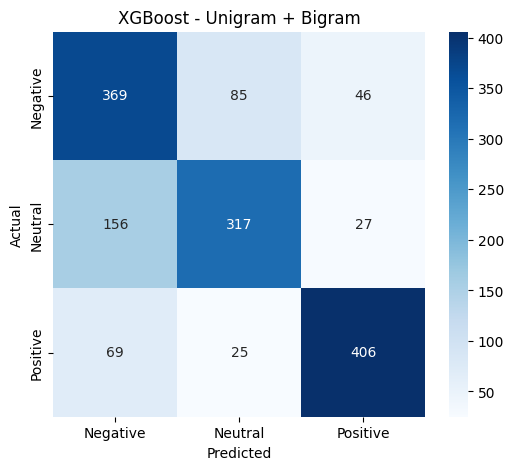



CONFIG : Unigram + Bigram + Trigram

=== Logistic Regression ===
Accuracy : 0.7260

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       500
     Neutral       0.78      0.59      0.67       500
    Positive       0.88      0.78      0.82       500

    accuracy                           0.73      1500
   macro avg       0.75      0.73      0.73      1500
weighted avg       0.75      0.73      0.73      1500



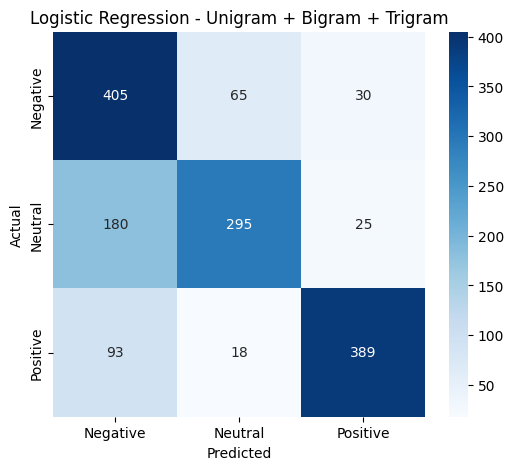


=== Multinomial Naive Bayes ===
Accuracy : 0.6940

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.79      0.68       500
     Neutral       0.89      0.40      0.56       500
    Positive       0.73      0.89      0.80       500

    accuracy                           0.69      1500
   macro avg       0.74      0.69      0.68      1500
weighted avg       0.74      0.69      0.68      1500



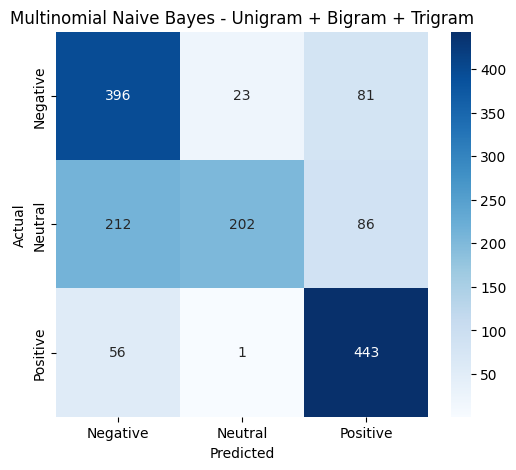


=== Support Vector Machine ===
Accuracy : 0.6987

Classification Report:
              precision    recall  f1-score   support

    Negative       0.59      0.69      0.64       500
     Neutral       0.68      0.68      0.68       500
    Positive       0.87      0.73      0.79       500

    accuracy                           0.70      1500
   macro avg       0.71      0.70      0.70      1500
weighted avg       0.71      0.70      0.70      1500



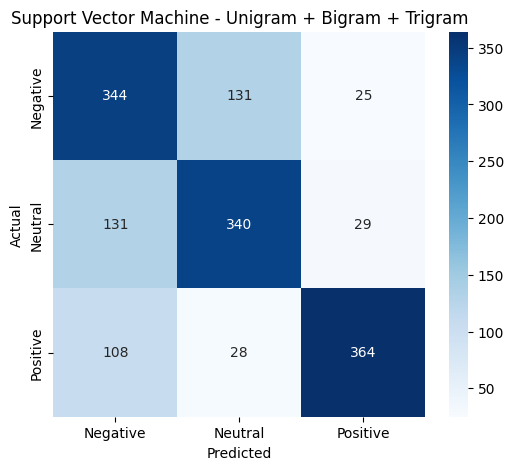


=== Random Forest ===
Accuracy : 0.7193

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.81      0.69       500
     Neutral       0.78      0.61      0.69       500
    Positive       0.87      0.73      0.79       500

    accuracy                           0.72      1500
   macro avg       0.75      0.72      0.72      1500
weighted avg       0.75      0.72      0.72      1500



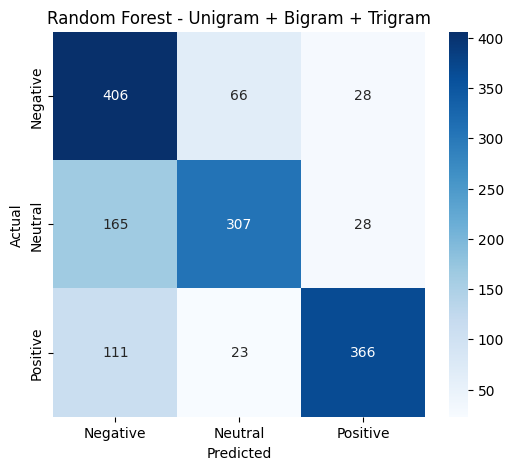


=== XGBoost ===
Accuracy : 0.7387

Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.74      0.69       500
     Neutral       0.75      0.66      0.70       500
    Positive       0.85      0.82      0.84       500

    accuracy                           0.74      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.75      0.74      0.74      1500



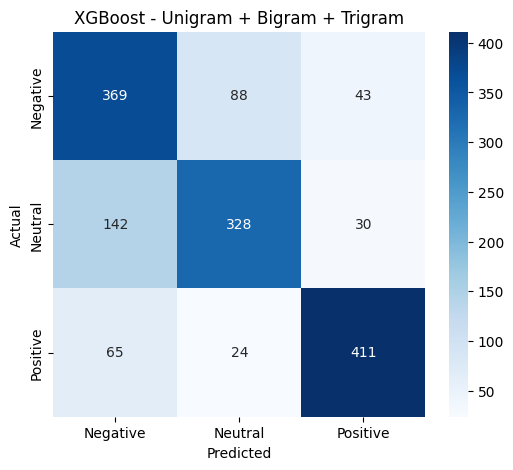


=== MODEL PERFORMANCE COMPARISON ===


Metric                                                       Accuracy  \
Configs                    Model                   Class                
Unigram                    Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.719333   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.695333   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.718667   
                                                   Positive       NaN   
                           Support Vector Machine  Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.705333   
                                                   Positive       NaN   
                           XGBoost                 Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.731333   
                                                   Positive       NaN   
Unigram + Bigram           Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.728000   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.695333   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.724667   
                                                   Positive       NaN   
                           Support Vector Machine  Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.706667   
                                                   Positive       NaN   
                           XGBoost                 Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.728000   
                                                   Positive       NaN   
Unigram + Bigram + Trigram Logistic Regression     Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.726000   
                                                   Positive       NaN   
                           Multinomial Naive Bayes Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.694000   
                                                   Positive       NaN   
                           Random Forest           Negative       NaN   
                                                   Neutral        NaN   
                                                   Overall   0.719333   
                                                   Positive       NaN   
                           Support Vector Machine  Negativ

In [ ]:
# ==========================================
# Training Model
# ==========================================

# Model
models4 = {
    'Logistic Regression'    : LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Support Vector Machine' : SVC(random_state=42),
    'Random Forest'          : RandomForestClassifier(random_state=42),
    'XGBoost'                : XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Target & Result
target_names4 = ['Negative', 'Neutral', 'Positive']
results4 = []

# Configs comparison
configs  = {
    'Unigram': (x4_train_uni, x4_test_uni),
    'Unigram + Bigram': (x4_train_bi, x4_test_bi),
    'Unigram + Bigram + Trigram': ( x4_train_tri, x4_test_tri)
}

for configs_name, (x4_train_vec, x4_test_vec) in configs .items():

    print("\n")
    print("=" * 60)
    print(f"CONFIG : {configs_name}")
    print("=" * 60)

    for model_name, model in models4.items():

        print(f"\n=== {model_name} ===")

        # Train
        model.fit(x4_train_vec, y4_train)

        # Predict
        y4_pred = model.predict(x4_test_vec)

        # Evaluation
        report = classification_report( y4_test,y4_pred, target_names=target_names4, output_dict=True)

        accuracy = accuracy_score(y4_test,y4_pred)

        # Store metrics
        for class_label in target_names4:
            for metric in ['precision', 'recall', 'f1-score', 'support']:
                results4.append({
                    'Configs': configs_name,
                    'Model': model_name,
                    'Metric': metric.replace('-', '-').capitalize(),
                    'Class': class_label,
                    'Score': report[class_label][metric]
                })

        # Accuracy
        results4.append({
            'Configs': configs_name,
            'Model': model_name,
            'Metric': 'Accuracy',
            'Class': 'Overall',
            'Score': accuracy
        })

        print(f"Accuracy : {accuracy:.4f}")

        print("\nClassification Report:")
        print(
            classification_report(
                y4_test,
                y4_pred,
                target_names=target_names4
            )
        )

        # Confusion Matrix
        cm = confusion_matrix(y4_test,y4_pred)

        plt.figure(figsize=(6,5))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names4, yticklabels=target_names4)
        plt.title(f'{model_name} - {configs_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()



# buat dataframe perbandingan hasil
comparison_df = pd.DataFrame(results4)
pivot_table = comparison_df.pivot_table(index=['Configs', 'Model', 'Class'], columns='Metric', values='Score')
print("\n=== MODEL PERFORMANCE COMPARISON ===")

display(pivot_table)

In [ ]:
# buat dataframe perbandingan hasil accurancy saja
accuracy_table = comparison_df[comparison_df['Metric'] == 'Accuracy']

accuracy_table = accuracy_table.pivot_table(index='Model',columns='Configs',values='Score')

display(accuracy_table)

Configs,Unigram,Unigram + Bigram,Unigram + Bigram + Trigram
Model,,,
Logistic Regression,0.719333,0.728000,0.726000
Multinomial Naive Bayes,0.695333,0.695333,0.694000
Random Forest,0.718667,0.724667,0.719333
Support Vector Machine,0.705333,0.706667,0.698667
XGBoost,0.731333,0.728000,0.738667


# Skenario 5 - Farras

In [ ]:
# ==========================================
# SKENARIO 5 - Preprocessing with NLP-ID StopWords and Stemming
# ==========================================

x5_train = x_train_final.copy()
y5_train = y_train_final.copy()

x5_test = X_test.copy()
y5_test = y_test.copy()

print("Jumlah data training :", len(x5_train))
print("Jumlah data testing  :", len(x5_test))

Jumlah data training : 6000
Jumlah data testing  : 1500


In [ ]:
stopword_remover = StopWord()
lemmatizer = Lemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    #Stemming
    text = lemmatizer.lemmatize(text)
    #Stopwords
    text = stopword_remover.remove_stopword(text)

    return text

x5_train_processed = x5_train.apply(preprocess_text)
x5_test_processed = x5_test.apply(preprocess_text)

print("\n--- Preprocessed comment sample ---")
print(x5_train_processed.head(5))
print("\n--- Non Preprocessed comment sample ---")
print(x5_train.head(5))


--- Preprocessed comment sample ---
0    diboock chain kabar kira2 rp beuat beli coin h...
1                                                     
2                 rakyat desa pakai daun bang ahhahaah
3                     netizen wajib lumpuh akun imf wb
4                                                     
Name: comment, dtype: object

--- Non Preprocessed comment sample ---
0    Yg ada diboock chain apa kabar?, kira2 Rp pada...
1                                             Kok agak
2          rakyat di desa kan pakai daun bang ahhahaah
3           Netizen wajib lumpuhkan akun IMF dan WB 🐶🐖
4                                   🇮🇩🇮🇩🇮🇩🇮🇩🇮🇩🇮🇩🇮🇩🇮🇩🇮🇩
Name: comment, dtype: object


In [ ]:
tfidf_vectorizer_processed5 = TfidfVectorizer(max_features=5000)

x5_train_tfidf = tfidf_vectorizer_processed5.fit_transform(x5_train_processed)
x5_test_tfidf = tfidf_vectorizer_processed5.transform(x5_test_processed)

print(f"Shape of X5_train_tfidf: {x5_train_tfidf.shape}")
print(f"Shape of X5_test_tfidf: {x5_test_tfidf.shape}")

Shape of X5_train_tfidf: (6000, 5000)
Shape of X5_test_tfidf: (1500, 5000)


In [ ]:
models = {
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


=== XGBoost ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.60      0.64       500
     Neutral       0.68      0.79      0.73       500
    Positive       0.81      0.78      0.80       500

    accuracy                           0.72      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.73      0.72      0.72      1500

Confusion Matrix:


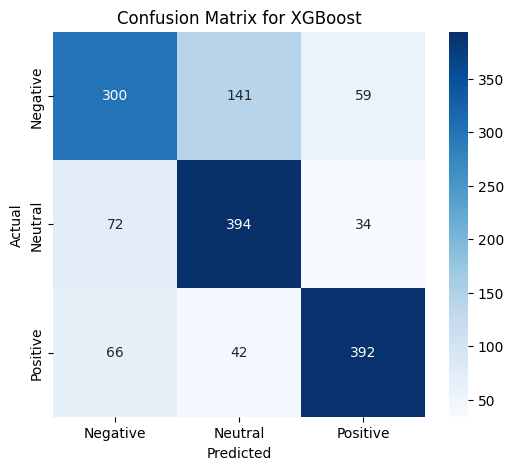


=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.78      0.68       500
     Neutral       0.77      0.54      0.64       500
    Positive       0.82      0.82      0.82       500

    accuracy                           0.71      1500
   macro avg       0.73      0.71      0.71      1500
weighted avg       0.73      0.71      0.71      1500

Confusion Matrix:


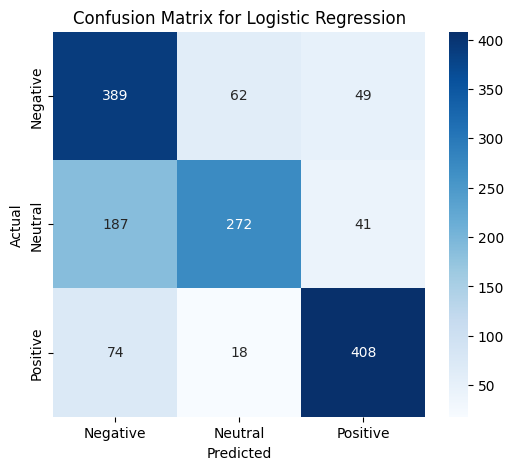


=== Naive Bayes ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.74      0.65       500
     Neutral       0.79      0.37      0.51       500
    Positive       0.69      0.86      0.76       500

    accuracy                           0.66      1500
   macro avg       0.69      0.66      0.64      1500
weighted avg       0.69      0.66      0.64      1500

Confusion Matrix:


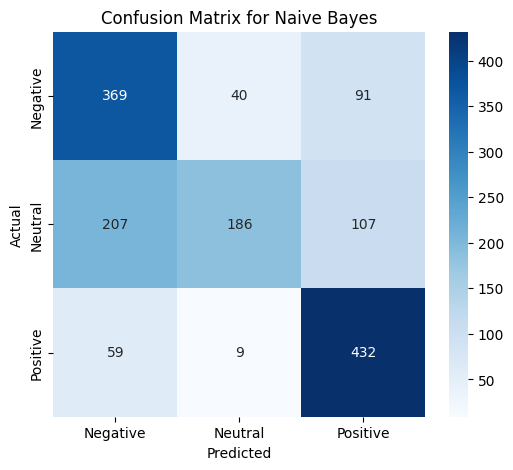


=== SVM ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.85      0.66       500
     Neutral       0.82      0.41      0.55       500
    Positive       0.85      0.80      0.82       500

    accuracy                           0.69      1500
   macro avg       0.74      0.69      0.68      1500
weighted avg       0.74      0.69      0.68      1500

Confusion Matrix:


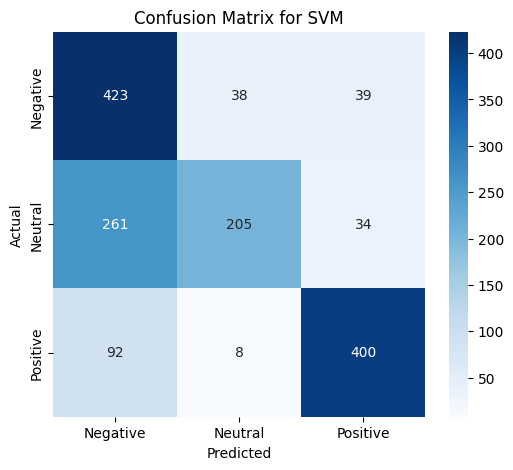


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.75      0.69       500
     Neutral       0.79      0.67      0.72       500
    Positive       0.82      0.80      0.81       500

    accuracy                           0.74      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.75      0.74      0.74      1500

Confusion Matrix:


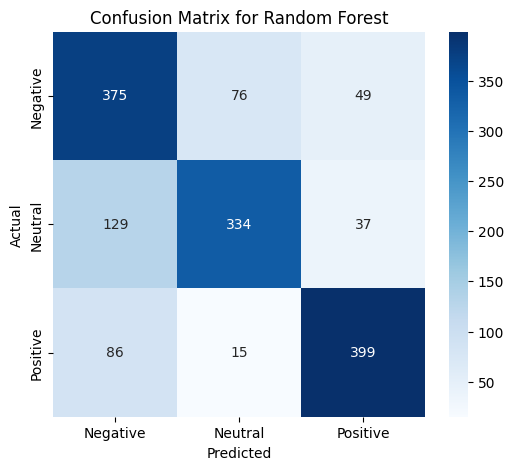


=== Model Performance Comparison ===
Metric                        Accuracy  F1-Score  Precision  Recall  Support
Model               Class                                                   
Logistic Regression Negative       NaN  0.676522   0.598462   0.778    500.0
                    Neutral        NaN  0.638498   0.772727   0.544    500.0
                    Overall   0.712667       NaN        NaN     NaN      NaN
                    Positive       NaN  0.817635   0.819277   0.816    500.0
Naive Bayes         Negative       NaN  0.650220   0.581102   0.738    500.0
                    Neutral        NaN  0.506122   0.791489   0.372    500.0
                    Overall   0.658000       NaN        NaN     NaN      NaN
                    Positive       NaN  0.764602   0.685714   0.864    500.0
Random Forest       Negative       NaN  0.688073   0.635593   0.750    500.0
                    Neutral        NaN  0.722162   0.785882   0.668    500.0
                    Overall   0.738667

In [ ]:
results5 = []
reports5 = {}

datasets5 = {
    'Preprocessed (nlp-id)': (x5_train_tfidf, x5_test_tfidf)
}

target_names = ['Negative', 'Neutral', 'Positive'] # Define target_names here

for name, model in models.items():
    print(f"\n=== {name} ===")
    # Train the model
    model.fit(x5_train_tfidf, y5_train)

    # Make predictions
    y_pred = model.predict(x5_test_tfidf)

    # Evaluate the model
    print("Classification Report:")
    report_str = classification_report(y5_test, y_pred, target_names=target_names)
    print(report_str)

    # Generate the dictionary report for parsing metrics
    report = classification_report(y5_test, y_pred, target_names=target_names, output_dict=True)
    accuracy = accuracy_score(y5_test, y_pred)
    reports5[name] = report

    # Store results for each class
    for class_label in target_names:
        results5.append({
            'Model': name,
            'Metric': 'Precision',
            'Class': class_label,
            'Score': report[class_label]['precision']
        })
        results5.append({
            'Model': name,
            'Metric': 'Recall',
            'Class': class_label,
            'Score': report[class_label]['recall']
        })
        results5.append({
            'Model': name,
            'Metric': 'F1-Score',
            'Class': class_label,
            'Score': report[class_label]['f1-score']
        })
        results5.append({
            'Model': name,
            'Metric': 'Support',
            'Class': class_label,
            'Score': report[class_label]['support']
        })

    # Store overall accuracy
    results5.append({
        'Model': name,
        'Metric': 'Accuracy',
        'Score': accuracy,
        'Class': 'Overall',
    })

    print("Confusion Matrix:")
    cm = confusion_matrix(y5_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Create a DataFrame from the corrected results5 list
comparison5_df = pd.DataFrame(results5)

# Pivot the table for better readability
pivot_table5 = comparison5_df.pivot_table(index=['Model', 'Class'], columns='Metric', values='Score')

print("\n=== Model Performance Comparison ===")
print(pivot_table5)